🚀 Starting comprehensive review analysis of ecosystem services literature (Optimized)...
📚 Found 12 literature files
📁 File list: ['download2015u2724.txt', 'download2016u3063.txt', 'download2017u3174.txt', 'download2018u3644.txt', 'download2019u4168.txt', 'download2020u4679.txt', 'download2021u5624.txt', 'download2022u5822.txt', 'download2023u5805.txt', 'download2024u6315.txt', 'download2025u7392.txt', 'download2026u817.txt']
📊 Expected total number of articles based on file names: 53227
--------------------------------------------------------------------------------
✅ download2015u2724.txt: expected 2724 articles, actually parsed 2724 articles
✅ download2016u3063.txt: expected 3063 articles, actually parsed 3063 articles
✅ download2017u3174.txt: expected 3174 articles, actually parsed 3174 articles
✅ download2018u3644.txt: expected 3644 articles, actually parsed 3644 articles
✅ download2019u4168.txt: expected 4168 articles, actually parsed 4168 articles
✅ download2020u4679.txt: expect

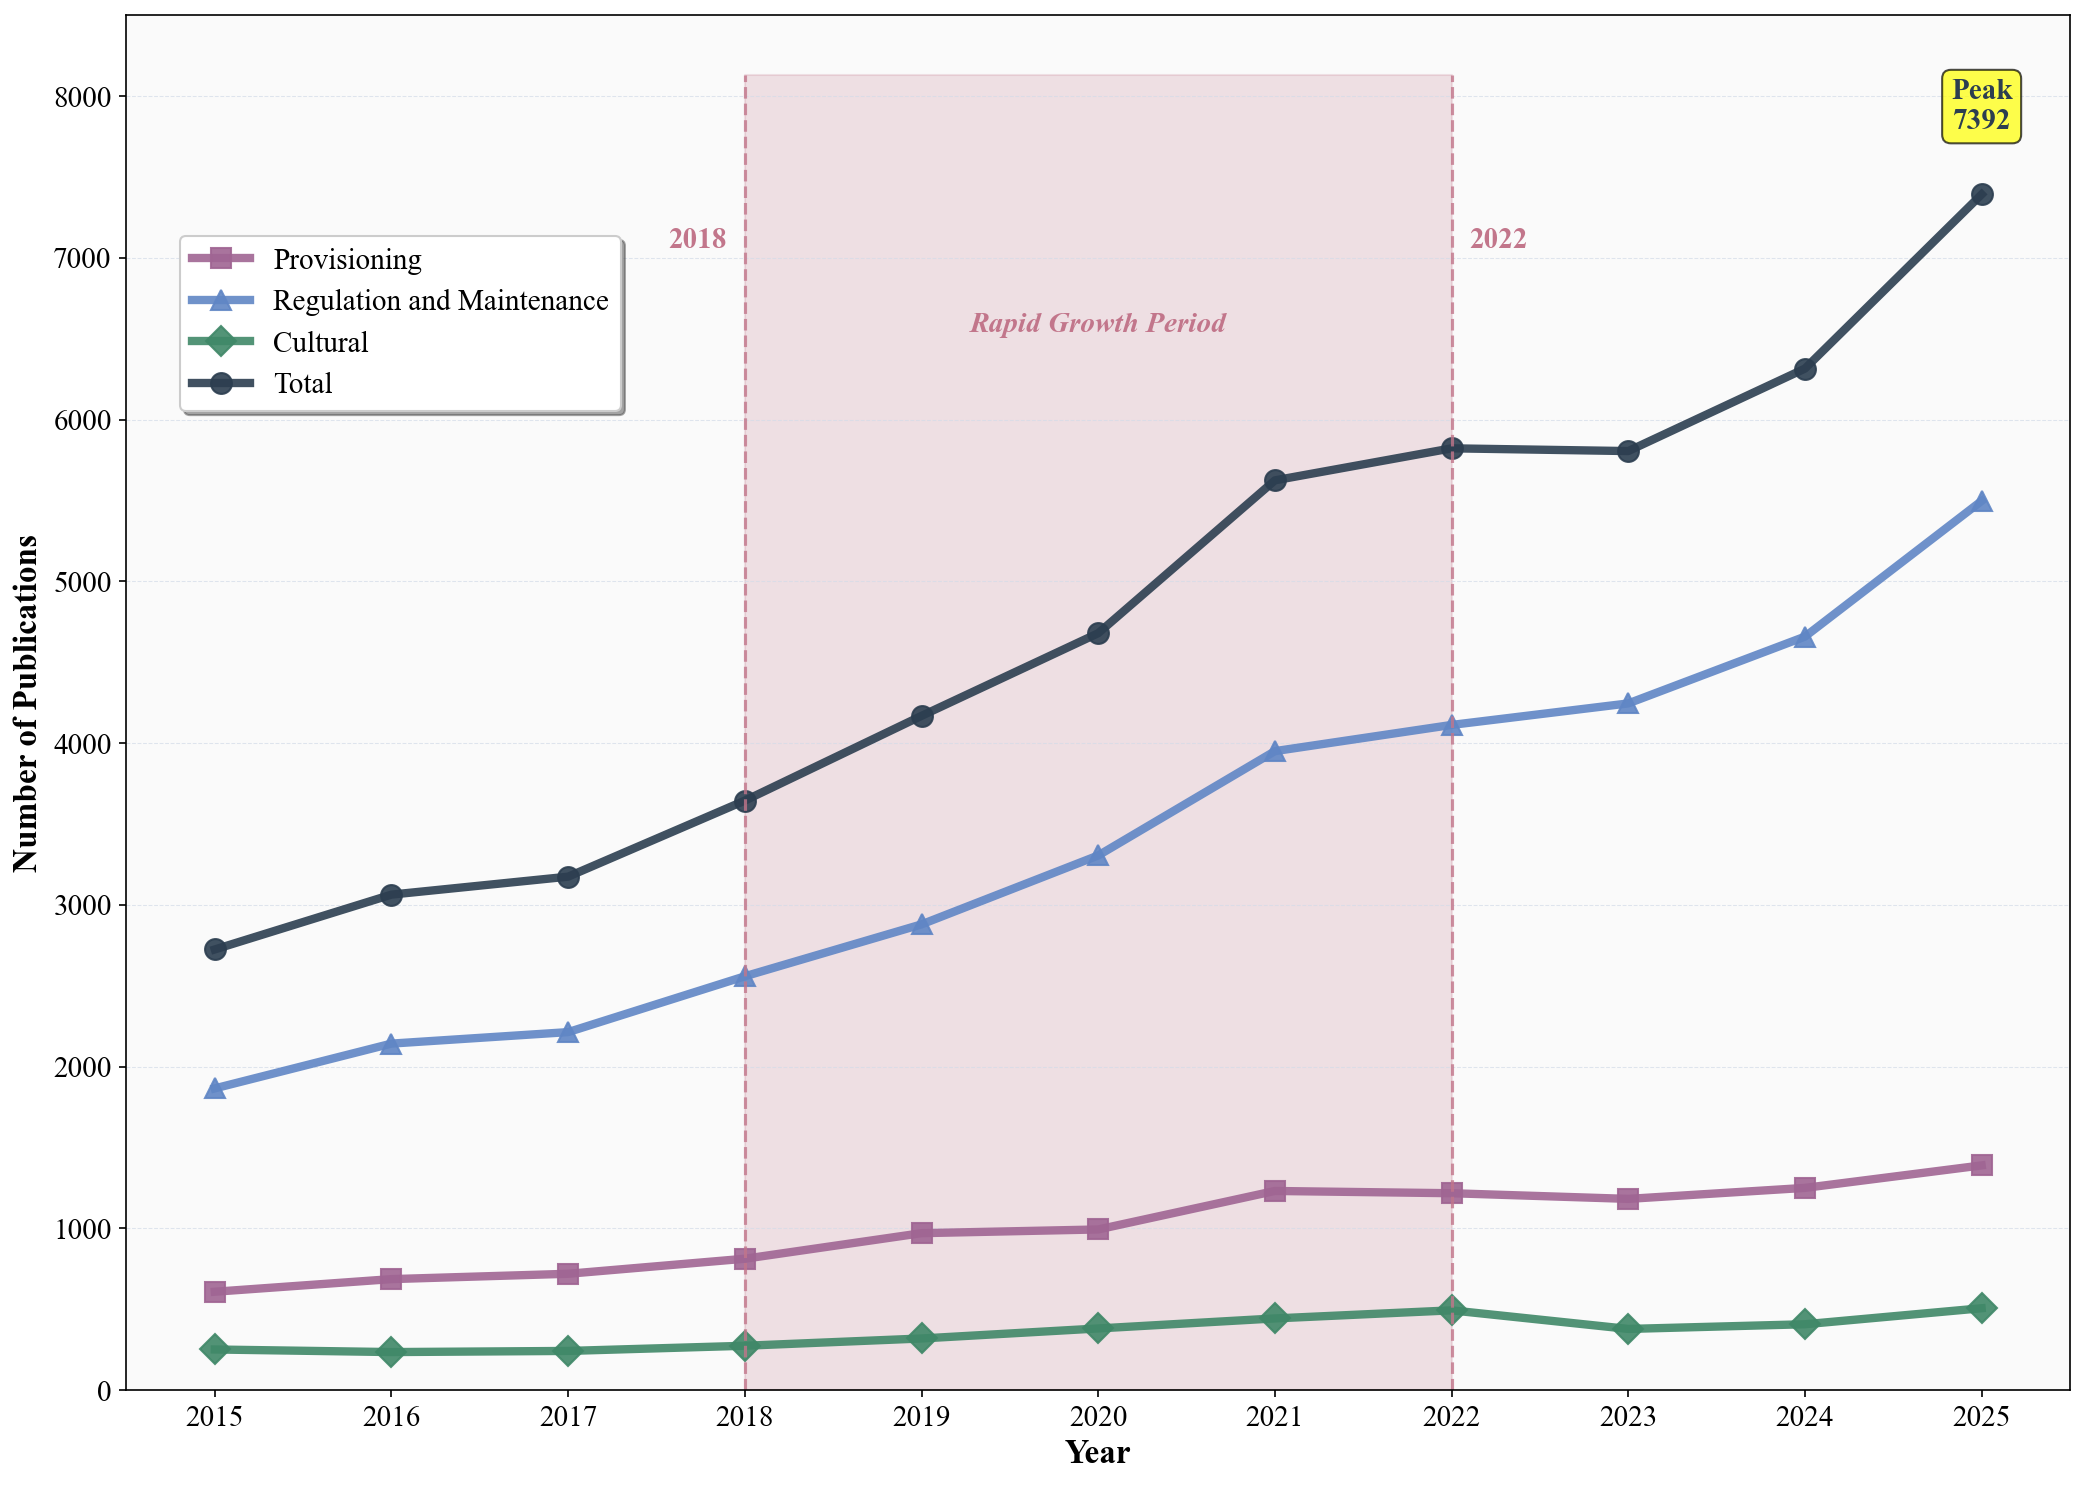

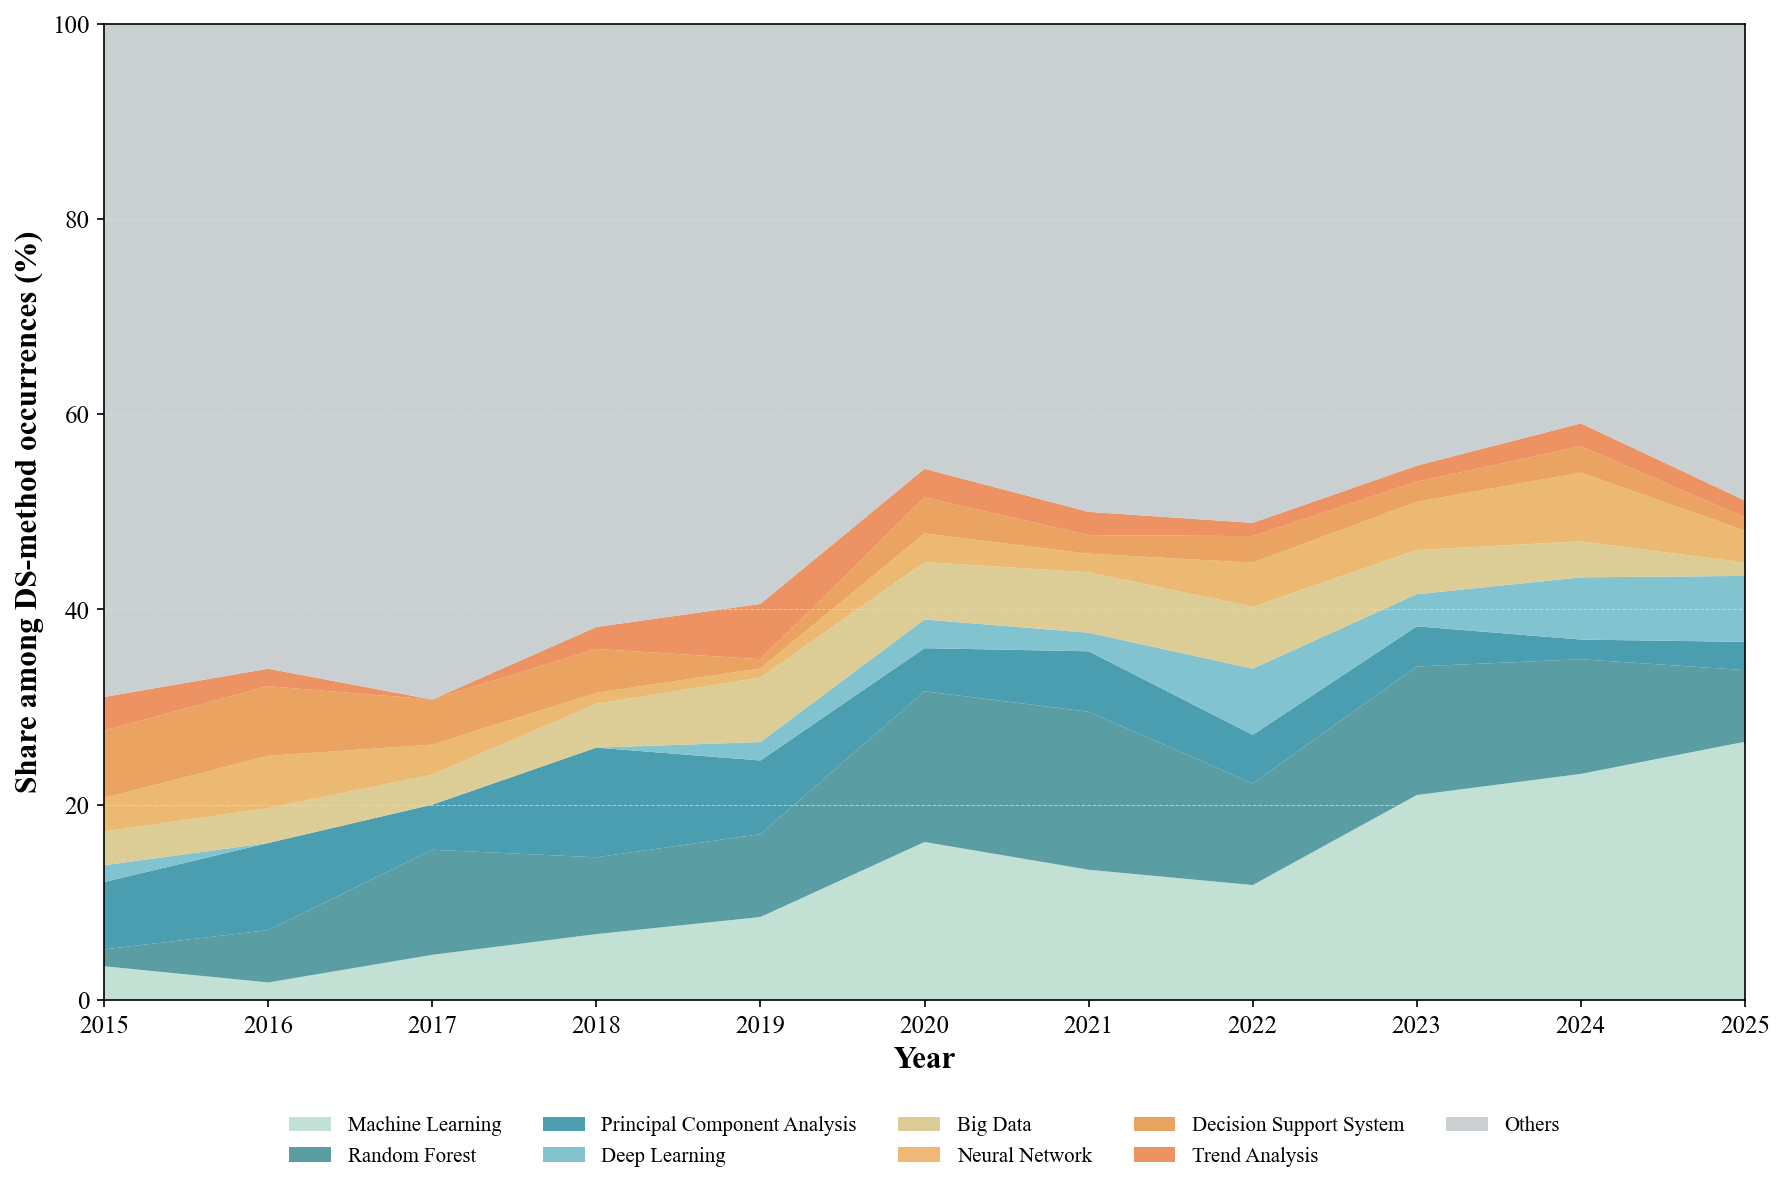

💾 Exporting analysis results...

✅ Comprehensive analysis results exported to ecosystem_services_comprehensive_review_optimized.xlsx

✅ Comprehensive analysis completed! Generated files:
  📊 ecosystem_services_trend_chart_optimized.pdf
  📊 ds_method_evolution_chart.pdf
  📁 ecosystem_services_comprehensive_review_optimized.xlsx


In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter, defaultdict
import numpy as np
import hashlib

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# Unified analysis year span (consistent across all cells): 2015-2026.
ANALYSIS_YEARS = ['2015', '2016', '2017', '2018', '2019', '2020',
                  '2021', '2022', '2023', '2024', '2025', '2026']


class EcosystemServicesComprehensiveAnalyzer:
    def __init__(self, data_directory="./"):

        self.data_directory = data_directory
        self.all_articles = []
        self.articles = []

        # ------------------------------------------------------------------
        # Data-science (DS/AI) method vocabulary and canonical mapping.
        # Kept identical to the association-analysis cell so that DS-method
        # identification uses one single, consistent operational taxonomy
        # everywhere (title/abstract/author keywords/Keywords Plus, with
        # abbreviation merging via the canonical map).
        # ------------------------------------------------------------------
        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning",
            "semi supervised learning", "self training", "active learning",
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction",
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR",
            "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation",
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis",
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model",
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm",
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR",
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR",
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO",
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        self.ai_keyword_canonical_map = {
            "ml": "machine learning",
            "dl": "deep learning",
            "rl": "reinforcement learning",
            "ensemble methods": "ensemble learning",
            "artificial neural network": "neural network",
            "ann": "neural network",
            "dnn": "deep neural network",
            "cnn": "convolutional neural network",
            "rnn": "recurrent neural network",
            "lstm": "long short-term memory",
            "gru": "gated recurrent unit",
            "gnn": "graph neural network",
            "gcn": "graph convolutional network",
            "resnet": "residual network",
            "vit": "vision transformer",
            "mlp": "multilayer perceptron",
            "seq2seq": "sequence-to-sequence",
            "transformers": "transformer",
            "gan": "generative adversarial network",
            "vae": "variational autoencoder",
            "svm": "support vector machine",
            "svr": "support vector regression",
            "knn": "k-nearest neighbor",
            "gmm": "gaussian mixture model",
            "pca": "principal component analysis",
            "ica": "independent component analysis",
            "svd": "singular value decomposition",
            "t-sne": "t-distributed stochastic neighbor embedding",
            "umap": "uniform manifold approximation and projection",
            "gbdt": "gradient boosting decision tree",
            "mdp": "markov decision process",
            "td learning": "temporal difference learning",
            "dqn": "deep q-network",
            "actor-critic framework": "actor-critic",
            "sarsa": "state-action-reward-state-action",
            "ppo": "proximal policy optimization",
            "ddpg": "deep deterministic policy gradient",
            "sac": "soft actor-critic",
            "marl": "multi-agent reinforcement learning",
            "maddpg": "multi-agent deep deterministic policy gradient",
            "mappo": "multi-agent proximal policy optimization",
            "sift": "scale-invariant feature transform",
            "hog": "histogram of oriented gradients",
            "ocr": "optical character recognition",
            "you only look once": "yolo",
            "nlp": "natural language processing",
            "ner": "named entity recognition",
            "pos tagging": "part-of-speech tagging",
            "bow": "bag of words",
            "llm": "large language model",
            "sgd": "stochastic gradient descent",
            "adaptive moment estimation": "adam optimizer",
            "pso": "particle swarm optimization",
            "aco": "ant colony optimization",
            "arima": "autoregressive integrated moving average",
            "sarima": "seasonal arima",
            "var": "vector autoregression",
            "dtw": "dynamic time warping",
            "map estimation": "maximum a posteriori",
            "em algorithm": "expectation maximization",
            "mcmc": "markov chain monte carlo",
            "hmm": "hidden markov model",
            "hyperparameter tuning": "hyperparameter optimization",
            "roc": "roc curve",
            "outlier detection": "anomaly detection",
            "rule based system": "rule-based system",
            "dss": "decision support system",
            "cbr": "case-based reasoning",
            "xai": "explainable ai",
            "automl": "automated machine learning",
            "nas": "neural architecture search",
        }
        self._initialize_ai_canonical_groups()

    def _initialize_ai_canonical_groups(self):
        """Group different spellings of the same DS method under one canonical
        form and verify the mapping neither omits nor introduces keywords."""
        original_forms = {kw.lower() for kw in self.ai_keywords}
        self.ai_canonical_groups = defaultdict(list)
        for kw in self.ai_keywords:
            canon = self.ai_keyword_canonical_map.get(kw.lower(), kw.lower())
            self.ai_canonical_groups[canon].append(kw.lower())
        self.canonical_ai_keywords = sorted(self.ai_canonical_groups.keys())

        covered = {s for spellings in self.ai_canonical_groups.values() for s in spellings}
        missing = original_forms - covered
        extra = set(self.canonical_ai_keywords) - original_forms
        if missing:
            raise ValueError(f"Canonical mapping incomplete, missing: {sorted(missing)}")
        if extra:
            raise ValueError(f"Canonical mapping introduces new keywords: {sorted(extra)}")

    def is_ai_match(self, search_text, ai_keyword):
        """Strict word-boundary matching identical to the association cell."""
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        if search_text == ai_kw:
            return True
        strict_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr",
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr",
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo",
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        if ai_kw in strict_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def match_canonical_methods(self, article):
        """Return the set of canonical DS methods present in an article's
        keyword fields (author keywords + Keywords Plus), merging spellings.
        Uses the keyword-field scope, consistent with the association cell."""
        keywords_text = ' '.join(article.get('all_keywords', []))
        matched = set()
        for canon_kw, spellings in self.ai_canonical_groups.items():
            if any(self.is_ai_match(keywords_text, sp) for sp in spellings):
                matched.add(canon_kw)
        return matched

    def generate_article_hash(self, article):
        identifier_parts = []
        if article.get('title'):
            title_cleaned = re.sub(r'\s+', ' ', article['title'].lower().strip())
            identifier_parts.append(title_cleaned)
        if article.get('year'):
            identifier_parts.append(article['year'])
        if article.get('authors') and len(article['authors']) > 0:
            first_author_cleaned = re.sub(r'\s+', ' ', article['authors'][0].lower().strip())
            identifier_parts.append(first_author_cleaned)
        if article.get('journal'):
            journal_cleaned = re.sub(r'\s+', ' ', article['journal'].lower().strip())
            identifier_parts.append(journal_cleaned)
        if len(identifier_parts) < 2:
            identifier_parts.append(str(hash(str(article))))
        identifier_string = '||'.join(identifier_parts)
        return hashlib.md5(identifier_string.encode('utf-8')).hexdigest()

    def read_literature_files(self):
        files = []
        expected_total = 0

        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in ANALYSIS_YEARS):
                files.append(f)
                match = re.search(r'u(\d+)\.txt', f)
                if match:
                    expected_total += int(match.group(1))

        files.sort()
        print(f"📚 Found {len(files)} literature files")
        print(f"📁 File list: {files}")
        print(f"📊 Expected total number of articles based on file names: {expected_total}")
        print("-" * 80)

        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    count = self.parse_articles(content, file)
                    match = re.search(r'u(\d+)\.txt', file)
                    expected = int(match.group(1)) if match else 0
                    status = "✅" if count == expected else "⚠️"
                    print(f"{status} {file}: expected {expected} articles, actually parsed {count} articles")
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")

        print("-" * 80)
        print(f"📊 Statistics:")
        print(f"  - Total number of all articles: {len(self.all_articles)}")
        print(f"  - Articles with keywords: {len(self.articles)}")
        print(f"  - Expected total number of articles: {expected_total}")
        es_2015 = sum(1 for a in self.all_articles if a.get('year') == '2015')
        es_2025 = sum(1 for a in self.all_articles if a.get('year') == '2025')
        print(f"  - ES articles in 2015: {es_2015}")
        print(f"  - ES articles in 2025: {es_2025}")

        if len(self.all_articles) != expected_total:
            print(f"  ⚠️ Warning: parsed total does not match expected total! Difference: {len(self.all_articles) - expected_total}")

    def parse_articles(self, content, filename):
        articles = re.split(r'\nER\s*\n', content)
        file_article_count = 0

        for article_text in articles:
            if not article_text.strip():
                continue
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue

            file_article_count += 1

            article_data = {
                'filename': filename,
                'keywords': set(),
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'abstract': '',
                'journal': '',
                'authors': [],
                'citations': 0,
                'references': [],
                'cices_categories': []
            }

            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                article_data['keywords_plus'].update(self.extract_keywords_from_field(id_match.group(1)))

            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                article_data['keywords'].update(self.extract_keywords_from_field(de_match.group(1)))

            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article_data['title'] = ti_match.group(1).replace('\n', ' ').strip()

            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article_data['year'] = py_match.group(1)

            ab_match = re.search(r'\nAB\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ab_match:
                article_data['abstract'] = ab_match.group(1).replace('\n', ' ').strip()

            so_match = re.search(r'\nSO\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if so_match:
                article_data['journal'] = so_match.group(1).replace('\n', ' ').strip()

            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                authors = [author.strip() for author in au_match.group(1).split('\n') if author.strip()]
                article_data['authors'] = authors

            tc_match = re.search(r'\nTC\s+(\d+)', article_text)
            if tc_match:
                article_data['citations'] = int(tc_match.group(1))

            cg_match = re.search(r'\nCG\s+([^\n]+)', article_text)
            if cg_match:
                category = cg_match.group(1).strip().capitalize()
                article_data['cices_categories'].append(category)

            self.all_articles.append(article_data)

            if article_data['keywords'] or article_data['keywords_plus']:
                article_data['all_keywords'] = article_data['keywords'] | article_data['keywords_plus']
                self.articles.append(article_data)

        return file_article_count

    def extract_keywords_from_field(self, field_content):
        if not field_content:
            return []

        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)

        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)

        return cleaned_keywords

    def classify_articles_by_cices(self):
        classification_results = {'Provisioning': [], 'Regulating': [], 'Cultural': []}
        added_articles = {'Provisioning': set(), 'Regulating': set(), 'Cultural': set()}

        for article in self.articles:
            article_hash = self.generate_article_hash(article)
            for category in article.get('cices_categories', []):
                if category in classification_results:
                    if article_hash not in added_articles[category]:
                        classification_results[category].append(article)
                        added_articles[category].add(article_hash)

        print(f"\n🔍 CICES classification statistics (read directly from file attributes):")
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            count = len(classification_results[category])
            print(f"  - {category}: {count} articles")

        return classification_results

    def calculate_total_cices_articles(self, classification_results):
        all_cices_hashes = set()
        for category, articles in classification_results.items():
            for article in articles:
                all_cices_hashes.add(self.generate_article_hash(article))
        return len(all_cices_hashes)

    def analyze_yearly_distribution(self):
        yearly_stats = defaultdict(lambda: {
            'total': 0,
            'cices_main_counts': defaultdict(int),
            'articles': []
        })

        for article in self.articles:
            year = article['year']
            if not year:
                year = 'Unknown'
            yearly_stats[year]['total'] += 1
            yearly_stats[year]['articles'].append(article)
            for category in article.get('cices_categories', []):
                yearly_stats[year]['cices_main_counts'][category] += 1

        return yearly_stats

    def analyze_journal_distribution(self):
        journals = set()
        for article in self.articles:
            if article['journal']:
                journals.add(article['journal'].lower().strip())

        journal_counts = Counter()
        for article in self.articles:
            if article['journal']:
                journal_counts[article['journal'].lower().strip()] += 1

        print(f"Total number of journals: {len(journals)}")
        return journal_counts

    def analyze_ds_method_trends(self, yearly_stats):
        """For each analysis year, count how many DS publications used each
        canonical DS method, both overall and within each CICES category.
        DS-method identification uses the keyword-field scope with canonical
        merging, consistent with the association-analysis cell.

        Returns
        -------
        year_method_counts : {year: Counter(method -> n_pubs)}          (overall)
        year_cat_method_counts : {year: {category: Counter(method -> n_pubs)}}
        year_ds_totals : {year: n_pubs_with_any_DS_method}              (overall)
        """
        year_method_counts = defaultdict(Counter)
        year_cat_method_counts = defaultdict(lambda: defaultdict(Counter))
        year_ds_totals = defaultdict(int)

        EXCLUDE_FROM_DS_FIG = {
            'precision', 'recall', 'f1 score', 'auc', 'roc curve', 'roc',
            'confusion matrix', 'accuracy', 'performance metrics',
            'cross validation', 'k-fold validation', 'overfitting', 'underfitting',
            'bias-variance tradeoff', 'hyperparameter optimization', 'hyperparameter tuning',
            'grid search', 'random search',
        }

        for article in self.articles:
            year = article['year'] if article['year'] else 'Unknown'
            methods = self.match_canonical_methods(article)
            # drop non-method evaluation/generic terms
            methods = {m for m in methods if m.lower() not in EXCLUDE_FROM_DS_FIG}
            if not methods:
                continue
            year_ds_totals[year] += 1
            cats = [c for c in article.get('cices_categories', [])
                    if c in ('Provisioning', 'Regulating', 'Cultural')]
            for m in methods:
                year_method_counts[year][m] += 1
                for c in cats:
                    year_cat_method_counts[year][c][m] += 1

        return year_method_counts, year_cat_method_counts, year_ds_totals

    def create_line_chart(self, yearly_stats, year_cat_method_counts, year_method_counts):
        valid_years = [str(y) for y in range(2015, 2026)]  # trend line: 2015-2025 (2026 partial)
        sorted_years = [y for y in valid_years if y in yearly_stats and yearly_stats[y]['total'] > 0]
        if not sorted_years:
            print("No valid year data available for visualization")
            return

        data = {
            'Year': [int(y) for y in sorted_years],
            'Total': [yearly_stats[y]['total'] for y in sorted_years],
            'Provisioning': [yearly_stats[y]['cices_main_counts'].get('Provisioning', 0) for y in sorted_years],
            'Regulating': [yearly_stats[y]['cices_main_counts'].get('Regulating', 0) for y in sorted_years],
            'Cultural': [yearly_stats[y]['cices_main_counts'].get('Cultural', 0) for y in sorted_years],
        }

        fig, ax = plt.subplots(figsize=(14, 10), dpi=150)
        categories = ['Provisioning', 'Regulating', 'Cultural', 'Total']

        display_names = {'Regulating': 'Regulation and Maintenance'}
        colors = ['#A06593', '#6086C5', '#408868', '#2C3E50']
        markers = ['s', '^', 'D', 'o']
        x = data['Year']

        for i, category in enumerate(categories):
            ax.plot(x, data[category], marker=markers[i], label=display_names.get(category, category),
                    linewidth=4, markersize=10, color=colors[i], alpha=0.9)

        if len(x) > 0:
            y_max = max(max(data[cat]) for cat in categories)
            if len(x) >= 5:
                start_highlight = x[len(x) // 3]
                end_highlight = x[2 * len(x) // 3]
                ax.fill_betweenx([0, y_max * 1.1], start_highlight, end_highlight, color="#c2768b", alpha=0.2)
                ax.plot([start_highlight, start_highlight], [0, y_max * 1.1], color="#c2768b", linestyle="--", alpha=0.8)
                ax.text(start_highlight - 0.1, y_max * 0.95, str(start_highlight), ha="right", va="bottom",
                        color="#c2768b", fontweight='bold', fontsize=14)
                ax.plot([end_highlight, end_highlight], [0, y_max * 1.1], color="#c2768b", linestyle="--", alpha=0.8)
                ax.text(end_highlight + 0.1, y_max * 0.95, str(end_highlight), ha="left", va="bottom",
                        color="#c2768b", fontweight='bold', fontsize=14)
                ax.text((start_highlight + end_highlight) / 2, y_max * 0.88, "Rapid Growth Period",
                        ha="center", va="bottom", color="#c2768b", fontweight='bold', style='italic', fontsize=14)

        total_values = data['Total']
        if total_values:
            peak_idx = total_values.index(max(total_values))
            ax.text(data['Year'][peak_idx], total_values[peak_idx] * 1.05, f"Peak\n{total_values[peak_idx]}",
                    ha="center", va="bottom", color="#2C3E50", fontweight='bold', fontsize=14,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

        ax.set_xlabel("Year", fontsize=16, fontweight='bold')
        ax.set_ylabel("Number of Publications", fontsize=16, fontweight='bold')
        if x:
            ax.set_xlim(min(x) - 0.5, max(x) + 0.5)
            if total_values:
                ax.set_ylim(0, max(total_values) * 1.15)
        ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.85), frameon=True, fancybox=True, shadow=True, fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v)}"))
        ax.grid(which="major", axis="y", linestyle="--", linewidth=0.5, color="#d3dce8", alpha=0.7)
        ax.set_facecolor('#fafafa')

        plt.tight_layout()
        plt.savefig('ecosystem_services_trend_chart_optimized.pdf', dpi=1200, bbox_inches='tight', transparent=False)
        plt.show()

    def create_ds_method_evolution_chart(self, year_method_counts, year_ds_totals,
                                          top_n=8, as_share=True):
        """Stacked-area figure showing the temporal COMPOSITION of DS methods.

        y-axis = each method's share among ALL DS-method occurrences in that year,
        i.e. share = (method occurrences) / (total method occurrences that year).
        Because the denominator is total method OCCURRENCES (not publications),
        every year sums to exactly 100% — so the stacked area is always full and
        the previous ">100%" problem (one paper using several methods) is removed:
        a paper using n methods contributes n occurrences, split across those n
        methods. Top-N methods are shown; the rest are aggregated as 'Others'.
        """
        years = [str(y) for y in range(2015, 2027)]  # full span incl. 2026
        years = [str(y) for y in range(2015, 2026)]  # 2015-2025 only (exclude 2026)
        years = [y for y in years if sum(year_method_counts.get(y, {}).values()) > 0]
        if not years:
            print("No DS-method data available for the evolution figure")
            return

        overall = Counter()
        for y in years:
            overall.update(year_method_counts.get(y, {}))
        if not overall:
            print("No DS methods matched; evolution figure skipped")
            return
        top_methods = [m for m, _ in overall.most_common(top_n)]

        series = {m: [] for m in top_methods}
        others = []
        for y in years:
            yc = year_method_counts.get(y, Counter())
            denom = sum(yc.values())       
            denom = denom if denom else 1
            top_sum = 0
            for m in top_methods:
                v = yc.get(m, 0)
                top_sum += v
                series[m].append(100.0 * v / denom if as_share else v)
            other_v = sum(yc.values()) - top_sum
            others.append(100.0 * other_v / denom if as_share else other_v)

        x = [int(y) for y in years]

        def _pretty(name):
            special = {'pca': 'PCA', 'svm': 'SVM', 'cnn': 'CNN', 'rnn': 'RNN',
                       'lstm': 'LSTM', 'ann': 'ANN', 'nlp': 'NLP', 'lda': 'LDA',
                       'gnn': 'GNN'}
            if name in special:
                return special[name]
            return name.title()

        palette = ['#BFDFD2', '#51999F', '#4198AC', '#7BC0CD',
                   '#DBCB92', '#ECB66C', '#EA9E58', '#ED8D5A']

        fig, ax1 = plt.subplots(figsize=(12, 8), dpi=150)

        stack_labels = [_pretty(m) for m in top_methods] + ['Others']
        stack_data = [series[m] for m in top_methods] + [others]
        stack_colors = (palette[:len(top_methods)] + ['#C8CDD0'])
        ax1.stackplot(x, *stack_data, labels=stack_labels, colors=stack_colors, alpha=0.95)
        ax1.set_xlabel("Year", fontsize=15, fontweight='bold')
        ax1.set_ylabel("Share among DS-method occurrences (%)", fontsize=15, fontweight='bold')
        ax1.set_xlim(min(x), max(x))
        ax1.set_ylim(0, 100)
        ax1.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax1.tick_params(axis='both', labelsize=12)
        ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10),
                   fontsize=10, ncol=5, frameon=False)
        ax1.grid(axis='y', linestyle='--', linewidth=0.5, color='#d3dce8', alpha=0.7)
        ax1.set_facecolor('#fafafa')

        plt.tight_layout()
        plt.savefig('ds_method_evolution_chart.pdf', dpi=1200, bbox_inches='tight', transparent=False)
        plt.show()

        # Also return a tidy dataframe for export / inspection.
        rows = []
        for m in top_methods + ['__others__']:
            label = 'Others' if m == '__others__' else _pretty(m)
            vals = others if m == '__others__' else series[m]
            for yi, y in enumerate(years):
                rows.append({'Year': int(y), 'Method': label,
                             'Share_or_Count': round(vals[yi], 4)})
        return pd.DataFrame(rows)

    def generate_comprehensive_report(self, main_categories_count, total_cices_articles):
        print("\n" + "=" * 80)
        print("🌍 Comprehensive Review Report of Ecosystem Services Literature (Optimized)")
        print("=" * 80)

        print(f"\n📊 I. Overall Statistics")
        print(f"  ├─ Total number of all articles: {len(self.all_articles)}")
        print(f"  ├─ Number of articles with keywords: {len(self.articles)}")
        print(f"  ├─ Proportion of articles with keywords: {len(self.articles)/len(self.all_articles)*100:.2f}%")
        print(f"  ├─ Total number of articles with CICES classification (deduplicated): {total_cices_articles}")
        print(f"  └─ CICES classification coverage rate: {total_cices_articles/len(self.articles)*100:.2f}%")

        print(f"\n🌳 II. CICES Classification Statistics")
        print(f"{'Main Category':<15} {'Articles':<10} {'% of Total':<12} {'% of CICES':<12}")
        print("-" * 55)
        for category, count in main_categories_count.items():
            percentage_total = (count / len(self.articles)) * 100
            percentage_cices = (count / total_cices_articles) * 100 if total_cices_articles > 0 else 0
            print(f"{category:<15} {count:<10} {percentage_total:<12.1f} {percentage_cices:<12.1f}")

    def export_comprehensive_results(self, yearly_stats, main_categories_count,
                                      total_cices_articles, ds_evolution_df=None):
        valid_years = [str(y) for y in range(2015, 2027)]
        sorted_years = [y for y in valid_years if y in yearly_stats]
        if 'Unknown' in yearly_stats:
            sorted_years.append('Unknown')
        n_years = len([y for y in sorted_years if y != 'Unknown'])

        with pd.ExcelWriter('./ecosystem_services_comprehensive_review_optimized.xlsx', engine='openpyxl') as writer:
            summary_data = {
                'Metric': ['Total number of all articles', 'Number of articles with keywords',
                           'Proportion of articles with keywords (%)',
                           'Total number of articles with CICES classification (deduplicated)',
                           'CICES classification coverage rate (%)', 'Number of years covered',
                           'Average number of articles per year', 'Number of Provisioning articles',
                           'Number of Regulating articles', 'Number of Cultural articles'],
                'Value': [
                    len(self.all_articles),
                    len(self.articles),
                    round(len(self.articles) / len(self.all_articles) * 100, 2),
                    total_cices_articles,
                    round(total_cices_articles / len(self.articles) * 100, 2),
                    n_years,
                    round(len(self.articles) / n_years, 1) if n_years > 0 else 0,
                    main_categories_count.get('Provisioning', 0),
                    main_categories_count.get('Regulating', 0),
                    main_categories_count.get('Cultural', 0),
                ]
            }
            pd.DataFrame(summary_data).to_excel(writer, sheet_name='Overall Statistics', index=False)

            yearly_data = []
            for year in sorted_years:
                yearly_data.append({
                    'Year': year,
                    'Articles': yearly_stats[year]['total'],
                    'Percentage': round((yearly_stats[year]['total'] / len(self.articles)) * 100, 2),
                    'Provisioning': yearly_stats[year]['cices_main_counts'].get('Provisioning', 0),
                    'Regulating': yearly_stats[year]['cices_main_counts'].get('Regulating', 0),
                    'Cultural': yearly_stats[year]['cices_main_counts'].get('Cultural', 0),
                })
            pd.DataFrame(yearly_data).to_excel(writer, sheet_name='Yearly Distribution', index=False)

            if ds_evolution_df is not None and not ds_evolution_df.empty:
                ds_evolution_df.to_excel(writer, sheet_name='DS Method Evolution', index=False)

        print("\n✅ Comprehensive analysis results exported to ecosystem_services_comprehensive_review_optimized.xlsx")

    def run_comprehensive_analysis(self):
        print("🚀 Starting comprehensive review analysis of ecosystem services literature (Optimized)...")
        print("=" * 80)

        self.read_literature_files()
        if not self.all_articles:
            print("❌ No valid article data found!")
            return
        if not self.articles:
            print("❌ No articles with keywords found!")
            return

        print(f"\n📊 WOS search already ensures all articles are ecosystem service related; "
              f"directly analyzing {len(self.articles)} articles with keywords")

        print("\n📊 Performing CICES classification...")
        classification_results = self.classify_articles_by_cices()
        main_categories_count = {c: len(classification_results[c]) for c in ['Provisioning', 'Regulating', 'Cultural']}
        total_cices_articles = self.calculate_total_cices_articles(classification_results)
        print(f"Classification results: Provisioning={main_categories_count['Provisioning']}, "
              f"Regulating={main_categories_count['Regulating']}, Cultural={main_categories_count['Cultural']}")
        print(f"Total number of articles with CICES classification (deduplicated): {total_cices_articles}")

        print("📊 Analyzing yearly distribution...")
        yearly_stats = self.analyze_yearly_distribution()

        print("📚 Analyzing journal distribution...")
        self.analyze_journal_distribution()

        print("🤖 Analyzing DS-method temporal trends (keyword-field, canonical merging)...")
        year_method_counts, year_cat_method_counts, year_ds_totals = self.analyze_ds_method_trends(yearly_stats)

        self.generate_comprehensive_report(main_categories_count, total_cices_articles)

        print("\n📊 Creating visualization charts...")
        self.create_line_chart(yearly_stats, year_cat_method_counts, year_method_counts)
        ds_evolution_df = self.create_ds_method_evolution_chart(year_method_counts, year_ds_totals,
                                                                top_n=8, as_share=True)

        print("💾 Exporting analysis results...")
        self.export_comprehensive_results(yearly_stats, main_categories_count,
                                          total_cices_articles, ds_evolution_df)

        print("\n" + "=" * 80)
        print("✅ Comprehensive analysis completed! Generated files:")
        print("  📊 ecosystem_services_trend_chart_optimized.pdf")
        print("  📊 ds_method_evolution_chart.pdf")
        print("  📁 ecosystem_services_comprehensive_review_optimized.xlsx")
        print("=" * 80)


if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = EcosystemServicesComprehensiveAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_comprehensive_analysis()

In [13]:
import os
import re
import sys
import glob

DIGITAL_TRACE_TERMS = {
    "social_media_general": [
        "social media", "social media data", "social-media data",
        "social media posts", "social media post", "social media content",
        "social media records", "social media images", "social media text",
        "social networking", "social network data", "social media platform",
        "social media platforms", "social media sites", "social media site",
        "microblog", "micro-blog", "microblogging", "micro-blogging",
        "user-generated content", "user generated content",
        "user-generated data", "user generated data",
        "social sensing", "social media check-in", "social media check-ins",
        "digital trace", "digital traces", "digital footprint",
        "digital footprints", "online activity data", "web 2.0 data",
        "social web data", "crowdsourced social media", "social media analytics",
    ],
    "platforms": [
        "twitter", "tweets", "tweet", "facebook", "instagram",
        "flickr", "youtube", "tiktok", "weibo", "sina weibo",
        "reddit", "pinterest", "panoramio", "foursquare",
        "linkedin", "snapchat", "whatsapp", "strava", "wikiloc",
        "komoot", "geocaching", "tripadvisor", "yelp", "airbnb",
        "booking.com",
    ],
    "geotagged_location": [
        "geotag", "geotags", "geotagged", "geo-tag", "geo-tags",
        "geo-tagged", "geotagged photo", "geotagged photos",
        "geotagged photograph", "geotagged photographs",
        "geotagged image", "geotagged images", "geotagged social media",
        "geo-located social media", "geolocated social media",
        "georeferenced photo", "georeferenced photos",
        "georeferenced photograph", "georeferenced photographs",
        "geo-referenced photo", "geo-referenced photographs",
        "geo-referenced images", "location-based social media",
        "location-based social network", "location-based social networks",
        "location-aware social media", "location tagging", "location tags",
        "location-stamped photo", "location-stamped photos",
        "gps-tagged photo", "gps-tagged photographs",
        "check-in", "check-ins", "checkin", "checkins",
        "check-in data", "check-in records",
    ],
    "mobile_telecom": [
        "mobile phone data", "mobile telephone data", "mobile-phone data",
        "mobile phone records", "mobile phone trajectories",
        "mobile positioning data", "mobile network data",
        "mobile location data", "mobile trajectory", "mobile trajectories",
        "mobile trajectory data", "mobile trajectory records",
        "cell phone data", "cellular network data",
        "cellular signaling data", "mobile signaling data",
        "call detail record", "call detail records", "cdr data",
        "smartphone data", "smartphone gps", "smartphone location data",
        "gps trajectory", "gps trajectories", "gps tracking data",
        "location data from mobile phones",
        "anonymized mobile phone data", "passive mobile data",
        "mobile app data", "location-based service data",
        "location-based services data", "mobile phone tracking",
        "mobile tracking data",
    ],
    "crowdsourcing_vgi": [
        "crowdsourcing", "crowdsourced", "crowd-sourcing",
        "crowd-sourced", "crowdsourced data",
        "crowdsourced geographic information",
        "volunteered geographic information",
        "volunteered geographical information", "vgi data",
        "citizen science data", "citizen-collected data",
        "participatory sensing",
    ],
    "reviews_online_contributions": [
        "online review", "online reviews", "user review", "user reviews",
        "web review", "internet reviews", "electronic word of mouth",
        "e-word of mouth", "visitor-generated content",
        "tourist-generated content", "online comments",
        "travel blog", "travel blogs", "travelogue", "travelogues",
        "photo sharing", "photo-sharing", "image sharing",
        "image-sharing", "photo-sharing platform", "photo-sharing platforms",
        "image-sharing platform", "image-sharing platforms",
    ],
}

ALL_TERMS = sorted({
    (family, term.lower().strip())
    for family, terms in DIGITAL_TRACE_TERMS.items()
    for term in terms
}, key=lambda x: (x[0], x[1]))

YEAR_RE = re.compile(r"\d{4}")


def read_text_auto(path):
    for enc in ("utf-8-sig", "utf-8", "gbk", "gb18030"):
        try:
            with open(path, "r", encoding=enc) as f:
                return f.read()
        except UnicodeDecodeError:
            continue
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()


def norm_title(title):
    return re.sub(r"\s+", " ", (title or "").strip().lower())


def term_match(text, term):
    pattern = r"(?<![a-z0-9])" + re.escape(term) + r"(?![a-z0-9])"
    return re.search(pattern, text) is not None


def parse_wos_records(content):
    records = []
    cur = []
    for line in content.split("\n"):
        if line.strip() == "ER":
            art = {}
            tag = None
            for ln in cur:
                if len(ln) > 2 and ln[2] == " " and ln[:2].isupper():
                    tag = ln[:2]
                    art[tag] = ln[3:].strip()
                elif tag and ln.startswith("   "):
                    art[tag] = art.get(tag, "") + " " + ln.strip()
            if art and "TI" in art:
                records.append(art)
            cur = []
        else:
            cur.append(line)
    return records


def get_year(art):
    py = (art.get("PY") or "").strip()
    if re.fullmatch(r"\d{4}", py):
        return py
    for field in ("EA", "PD"):
        m = YEAR_RE.search(art.get(field, ""))
        if m:
            return m.group(0)
    return "Unknown"


def load_cultural_records(wos_dir):
    files = sorted(glob.glob(os.path.join(wos_dir, "download*.txt")))
    if not files:
        files = sorted(glob.glob(os.path.join(wos_dir, "*.txt")))
    if not files:
        raise SystemExit("No WOS text files found in " + wos_dir)

    seen = {}
    for fp in files:
        for art in parse_wos_records(read_text_auto(fp)):
            cg = (art.get("CG") or "").strip().capitalize()
            if cg != "Cultural":
                continue
            nt = norm_title(art.get("TI"))
            if not nt or nt in seen:
                continue
            seen[nt] = {
                "year": get_year(art),
                "text": " ".join([
                    art.get("TI", ""), art.get("AB", ""),
                    art.get("DE", ""), art.get("ID", ""),
                ]).lower(),
            }
    return list(seen.values())


def run(wos_dir):
    records = load_cultural_records(wos_dir)
    if not records:
        raise SystemExit("No Cultural records found")

    yearly_total = {}
    yearly_hit = {}
    for rec in records:
        y = rec["year"]
        yearly_total[y] = yearly_total.get(y, 0) + 1
        if any(term_match(rec["text"], term) for _, term in ALL_TERMS):
            yearly_hit[y] = yearly_hit.get(y, 0) + 1

    years = sorted([y for y in yearly_total if y.isdigit()], key=int)
    if "Unknown" in yearly_total:
        years.append("Unknown")

    print("=== Yearly Statistics ===")
    print(f"{'Year':<10}{'Cultural':>10}{'DigitalTrace':>14}{'Share%':>9}")
    print("-" * 43)

    total_all = 0
    hit_all = 0
    for y in years:
        total = yearly_total[y]
        hit = yearly_hit.get(y, 0)
        share = hit / total * 100 if total else 0.0
        print(f"{y:<10}{total:>10}{hit:>14}{share:>9.2f}")
        total_all += total
        hit_all += hit

    share_all = hit_all / total_all * 100 if total_all else 0.0
    print(f"{'Overall':<10}{total_all:>10}{hit_all:>14}{share_all:>9.2f}")


if __name__ == "__main__":
    wos_dir = sys.argv[1] if len(sys.argv) > 1 else "./final_with_CG"
    if not os.path.isdir(wos_dir):
        fallback = "./annotated_wos_data"
        if os.path.isdir(fallback):
            wos_dir = fallback
        else:
            raise SystemExit("Directory not found: " + wos_dir)
    run(wos_dir)

=== Yearly Statistics ===
Year        Cultural  DigitalTrace   Share%
-------------------------------------------
2015             251             5     1.99
2016             235             7     2.98
2017             242             8     3.31
2018             274            11     4.01
2019             319            23     7.21
2020             381            26     6.82
2021             443            26     5.87
2022             493            52    10.55
2023             378            42    11.11
2024             407            39     9.58
2025             506            40     7.91
2026              72             7     9.72
Overall         4001           286     7.15


In [2]:
import os
import re
import pandas as pd
from collections import Counter, defaultdict
import hashlib

class EcosystemServicesAIAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.all_articles = []
        self.articles = []
        
        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR",
            "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

    def generate_article_hash(self, article):
        """Generate a unique article identifier for deduplication - optimized version (consistent with other analyses)"""
        identifier_parts = []
        if article.get('title'):
            title_cleaned = re.sub(r'\s+', ' ', article['title'].lower().strip())
            identifier_parts.append(title_cleaned)
        if article.get('year'):
            identifier_parts.append(article['year'])
        if article.get('authors') and len(article['authors']) > 0:
            first_author_cleaned = re.sub(r'\s+', ' ', article['authors'][0].lower().strip())
            identifier_parts.append(first_author_cleaned)
        if article.get('journal'):
            journal_cleaned = re.sub(r'\s+', ' ', article['journal'].lower().strip())
            identifier_parts.append(journal_cleaned)
        if len(identifier_parts) < 2:
            identifier_parts.append(str(hash(str(article))))
            
        identifier_string = '||'.join(identifier_parts)
        return hashlib.md5(identifier_string.encode('utf-8')).hexdigest()

    def read_literature_files(self):
        """Read all literature files"""
        files = []
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']):
                files.append(f)
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    self.parse_articles(content, file)
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print(f"✅ Parsed {len(self.all_articles)} articles in total")
        print(f"✅ Articles with keywords: {len(self.articles)}")

    def parse_articles(self, content, filename):
        """Parse article content and simultaneously extract the CG category attribute"""
        articles = re.split(r'\nER\s*\n', content)
        
        for article_text in articles:
            if not article_text.strip():
                continue
            
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            article_data = {
                'filename': filename,
                'keywords': set(),
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'abstract': '',
                'journal': '',
                'authors': [],
                'cices_categories': []
            }
            
            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                id_content = id_match.group(1)
                keywords_plus = self.extract_keywords_from_field(id_content)
                article_data['keywords_plus'].update(keywords_plus)
            
            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                de_content = de_match.group(1)
                keywords = self.extract_keywords_from_field(de_content)
                article_data['keywords'].update(keywords)
            
            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article_data['title'] = ti_match.group(1).replace('\n', ' ').strip()
            
            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article_data['year'] = py_match.group(1)
            
            ab_match = re.search(r'\nAB\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ab_match:
                article_data['abstract'] = ab_match.group(1).replace('\n', ' ').strip()
            
            so_match = re.search(r'\nSO\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if so_match:
                article_data['journal'] = so_match.group(1).replace('\n', ' ').strip()
            
            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                authors_text = au_match.group(1)
                authors = [author.strip() for author in authors_text.split('\n') if author.strip()]
                article_data['authors'] = authors

            cg_match = re.search(r'\nCG\s+([^\n]+)', article_text)
            if cg_match:
                category = cg_match.group(1).strip().capitalize()
                article_data['cices_categories'].append(category)
            
            self.all_articles.append(article_data)
            
            if article_data['keywords'] or article_data['keywords_plus']:
                article_data['all_keywords'] = article_data['keywords'] | article_data['keywords_plus']
                self.articles.append(article_data)

    def extract_keywords_from_field(self, field_content):
        """Extract keywords from ID or DE field content"""
        if not field_content:
            return []
            
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
                
        return cleaned_keywords

    def is_ai_keyword_match(self, search_text, ai_keyword):
        """
        Check whether an AI keyword matches within the search text - optimized version to avoid false matches
        Include all abbreviations in the protected list and perform the strictest word boundary validation.
        """
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()

        if search_text == ai_kw:
            return True

        strict_match_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]

        if ai_kw in strict_match_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))

        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))

        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def classify_articles_by_cices(self):
        """Classify literature based on the directly-read CG attribute, mapping to the original three major categories"""
        classification_results = {
            'Provisioning': [],
            'Regulating': [],
            'Cultural': []
        }
        
        added_articles = {
            'Provisioning': set(),
            'Regulating': set(), 
            'Cultural': set()
        }
        
        for article in self.articles:
            article_hash = self.generate_article_hash(article)
            for category in article.get('cices_categories', []):
                if category in classification_results:
                    if article_hash not in added_articles[category]:
                        classification_results[category].append(article)
                        added_articles[category].add(article_hash)
        
        print(f"\n🔍 CICES classification statistics (read directly from file attributes):")
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            count = len(classification_results[category])
            print(f"  - {category}: {count} articles")
        
        return classification_results

    def calculate_total_cices_articles(self, classification_results):
        """Calculate the total number of articles with CICES classification (deduplicated)"""
        all_cices_hashes = set()
        
        for category, articles in classification_results.items():
            for article in articles:
                article_hash = self.generate_article_hash(article)
                all_cices_hashes.add(article_hash)
        
        return len(all_cices_hashes)

    def analyze_ai_usage(self):
        """Analyze AI technology usage - optimized version: uses improved AI keyword matching logic"""
        print("🤖 Starting analysis of AI technology usage (using optimized matching logic)...")
        
        ai_results = {
            'ai_full_text': [],
            'ai_keywords_only': [],
            'ai_keyword_frequency_full_text': Counter(),
            'ai_keyword_frequency_keywords_only': Counter()
        }

        for article in self.articles:
            title_abstract = (article.get('title', '') + ' ' + article.get('abstract', '')).lower()
            keywords_text = ' '.join(article['all_keywords']).lower()
            full_text = title_abstract + ' ' + keywords_text

            matched_ai_full = []
            matched_ai_keywords = []

            for ai_keyword in self.ai_keywords:
                if self.is_ai_keyword_match(full_text, ai_keyword):
                    matched_ai_full.append(ai_keyword)
                    ai_results['ai_keyword_frequency_full_text'][ai_keyword] += 1

                if self.is_ai_keyword_match(keywords_text, ai_keyword):
                    matched_ai_keywords.append(ai_keyword)
                    ai_results['ai_keyword_frequency_keywords_only'][ai_keyword] += 1

            if matched_ai_full:
                ai_results['ai_full_text'].append({
                    'article': article,
                    'matched_keywords': matched_ai_full
                })

            if matched_ai_keywords:
                ai_results['ai_keywords_only'].append({
                    'article': article,
                    'matched_keywords': matched_ai_keywords
                })

        print(f"🔍 AI technology matching statistics:")
        print(f"  - AI articles (broad bibliographic-field indicator): {len(ai_results['ai_full_text'])}")
        print(f"  - AI articles (keyword-field indicator): {len(ai_results['ai_keywords_only'])}")

        return ai_results

    def analyze_ai_by_cices(self, ai_results, classification_results):
        """Analyze AI usage by CICES category - optimized version: uses hash mapping"""
        ai_by_cices = {
            'Provisioning': {'ai_full_text': [], 'ai_keywords_only': []},
            'Regulating': {'ai_full_text': [], 'ai_keywords_only': []},
            'Cultural': {'ai_full_text': [], 'ai_keywords_only': []}
        }

        article_hash_to_categories = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            for article in classification_results[category]:
                article_hash = self.generate_article_hash(article)
                if article_hash not in article_hash_to_categories:
                    article_hash_to_categories[article_hash] = []
                article_hash_to_categories[article_hash].append(category)

        for result_type in ['ai_full_text', 'ai_keywords_only']:
            for article_data in ai_results[result_type]:
                article = article_data['article']
                article_hash = self.generate_article_hash(article)
                for category in article_hash_to_categories.get(article_hash, []):
                    ai_by_cices[category][result_type].append(article_data)
        
        return ai_by_cices

    def analyze_yearly_ai_trends(self, ai_results):
        """Analyze AI technology usage trends and advancement rate changes by year"""
        yearly_ai_stats = defaultdict(lambda: {
            'total_articles': 0,
            'ai_full_text': 0,
            'ai_keywords_only': 0
        })

        for article in self.articles:
            year = article.get('year') or 'Unknown'
            yearly_ai_stats[year]['total_articles'] += 1

        for article_data in ai_results['ai_full_text']:
            year = article_data['article'].get('year') or 'Unknown'
            yearly_ai_stats[year]['ai_full_text'] += 1

        for article_data in ai_results['ai_keywords_only']:
            year = article_data['article'].get('year') or 'Unknown'
            yearly_ai_stats[year]['ai_keywords_only'] += 1

        return yearly_ai_stats

    def generate_ai_report(self, ai_results, ai_by_cices, main_categories_count, total_cices_articles):
        """Generate AI analysis report - optimized version"""
        print("\n" + "="*80)
        print("🤖 Ecosystem Services Literature AI Technology Analysis Report (Optimized)")
        print("="*80)

        print(f"\n📊 I. Overall DS/AI Technology Usage Statistics")
        print(f"  ├─ Total Articles with Keywords: {len(self.articles)}")
        print(f"  ├─ Total CICES Articles (Deduplicated): {total_cices_articles}")
        print(f"  ├─ AI Articles (broad bibliographic-field indicator): {len(ai_results['ai_full_text'])}")
        print(f"  ├─ AI Articles (keyword-field indicator): {len(ai_results['ai_keywords_only'])}")
        print(f"  ├─ AI Visibility (broad bibliographic-field): {len(ai_results['ai_full_text'])/len(self.articles)*100:.2f}%")
        print(f"  └─ AI Visibility (keyword-field): {len(ai_results['ai_keywords_only'])/len(self.articles)*100:.2f}%")

        print(f"\n🌳 II. AI Technology Visibility by CICES Categories")
        print(f"  📍 Broad bibliographic-field indicator:")
        print(f"  {'Category':<12} {'Total':<8} {'AI':<8} {'AI %':<8}")
        print("  " + "-" * 40)
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            total_docs = main_categories_count.get(category, 0)
            ai_full = len(ai_by_cices[category]['ai_full_text'])
            ai_rate = (ai_full / total_docs * 100) if total_docs > 0 else 0
            print(f"  {category:<12} {total_docs:<8} {ai_full:<8} {ai_rate:<8.2f}")

        print(f"\n  📍 Keyword-field indicator:")
        print(f"  {'Category':<12} {'Total':<8} {'AI':<8} {'AI %':<8}")
        print("  " + "-" * 40)
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            total_docs = main_categories_count.get(category, 0)
            ai_keywords = len(ai_by_cices[category]['ai_keywords_only'])
            ai_rate = (ai_keywords / total_docs * 100) if total_docs > 0 else 0
            print(f"  {category:<12} {total_docs:<8} {ai_keywords:<8} {ai_rate:<8.2f}")

        yearly_stats = self.analyze_yearly_ai_trends(ai_results)

        print(f"\n📈 III. Annual AI Visibility Trends")
        valid_years = sorted([year for year in yearly_stats.keys() if year.isdigit() and year != 'Unknown'])
        if valid_years:
            print(f"  {'Year':<6} {'Total':<8} {'AI(broad)':<10} {'AI(kw)':<8} {'broad %':<9} {'kw %':<8}")
            print("  " + "-" * 55)
            for year in valid_years:
                stats = yearly_stats[year]
                total = stats['total_articles']
                ai_full = stats['ai_full_text']
                ai_kw = stats['ai_keywords_only']
                rate_full = (ai_full / total * 100) if total > 0 else 0
                rate_kw = (ai_kw / total * 100) if total > 0 else 0
                print(f"  {year:<6} {total:<8} {ai_full:<10} {ai_kw:<8} {rate_full:<9.2f} {rate_kw:<8.2f}")
        else:
            print("  No valid year data available")

        return yearly_stats

    def export_ai_results(self, ai_results, ai_by_cices, main_categories_count, yearly_stats, total_cices_articles):
        """Export AI analysis results to Excel - optimized version"""
        with pd.ExcelWriter('./ecosystem_services_ai_analysis_optimized.xlsx', engine='openpyxl') as writer:

            summary_data = {
                'Metric': [
                    'Total Articles with Keywords',
                    'Total CICES Articles (Deduplicated)',
                    'AI Articles (broad bibliographic-field indicator)',
                    'AI Articles (keyword-field indicator)',
                    'AI Visibility (broad bibliographic-field) %',
                    'AI Visibility (keyword-field) %'
                ],
                'Value': [
                    len(self.articles),
                    total_cices_articles,
                    len(ai_results['ai_full_text']), len(ai_results['ai_keywords_only']),
                    round(len(ai_results['ai_full_text'])/len(self.articles)*100, 2),
                    round(len(ai_results['ai_keywords_only'])/len(self.articles)*100, 2)
                ]
            }
            pd.DataFrame(summary_data).to_excel(writer, sheet_name='Overall_Statistics', index=False)

            cices_data = []
            for category in ['Provisioning', 'Regulating', 'Cultural']:
                total_docs = main_categories_count.get(category, 0)
                cices_data.append({
                    'Category': category,
                    'Total_Articles': total_docs,
                    'AI_Articles_Broad': len(ai_by_cices[category]['ai_full_text']),
                    'AI_Rate_Broad_%': round(len(ai_by_cices[category]['ai_full_text'])/total_docs*100, 2) if total_docs > 0 else 0,
                    'AI_Articles_Keyword': len(ai_by_cices[category]['ai_keywords_only']),
                    'AI_Rate_Keyword_%': round(len(ai_by_cices[category]['ai_keywords_only'])/total_docs*100, 2) if total_docs > 0 else 0
                })
            pd.DataFrame(cices_data).to_excel(writer, sheet_name='CICES_AI_Visibility', index=False)

            ai_tech_data_full = [{'AI_Technology': ai_tech, 'Frequency_Broad': count,
                                  'Usage_Rate_Broad_%': round((count/len(self.articles))*100, 2)}
                                 for ai_tech, count in ai_results['ai_keyword_frequency_full_text'].most_common()]
            pd.DataFrame(ai_tech_data_full).to_excel(writer, sheet_name='AI_Tech_Freq_Broad', index=False)

            ai_tech_data_keywords = [{'AI_Technology': ai_tech, 'Frequency_Keyword': count,
                                      'Usage_Rate_Keyword_%': round((count/len(self.articles))*100, 2)}
                                     for ai_tech, count in ai_results['ai_keyword_frequency_keywords_only'].most_common()]
            pd.DataFrame(ai_tech_data_keywords).to_excel(writer, sheet_name='AI_Tech_Freq_Keyword', index=False)

            valid_years = sorted([year for year in yearly_stats.keys() if year.isdigit() and year != 'Unknown'])
            if valid_years:
                yearly_data = []
                for year in valid_years:
                    stats = yearly_stats[year]
                    yearly_data.append({
                        'Year': year,
                        'Total_Articles': stats['total_articles'],
                        'AI_Broad': stats['ai_full_text'],
                        'AI_Keyword': stats['ai_keywords_only'],
                        'AI_Rate_Broad_%': round((stats['ai_full_text'] / stats['total_articles'] * 100), 2) if stats['total_articles'] > 0 else 0,
                        'AI_Rate_Keyword_%': round((stats['ai_keywords_only'] / stats['total_articles'] * 100), 2) if stats['total_articles'] > 0 else 0
                    })
                pd.DataFrame(yearly_data).to_excel(writer, sheet_name='Annual_AI_Trends', index=False)

        print("\n✅ AI analysis results exported to ecosystem_services_ai_analysis_optimized.xlsx")

    def run_ai_analysis(self):
        """Run the dedicated AI analysis - optimized version"""
        print("🤖 Starting Ecosystem Services Literature AI Technology Analysis (Optimized)...")
        print("="*80)

        self.read_literature_files()
        
        if not self.all_articles:
            print("❌ No valid articles found!")
            return
        
        if not self.articles:
            print("❌ No articles with keywords found!")
            return
        
        print(f"\n📊 WOS search already ensures all articles are ecosystem service related")
        print(f"📊 Analyzing {len(self.articles)} articles with keywords")

        print("📊 Performing CICES classification with optimized deduplication...")
        classification_results = self.classify_articles_by_cices()
        
        main_categories_count = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            main_categories_count[category] = len(classification_results[category])

        total_cices_articles = self.calculate_total_cices_articles(classification_results)
        print(f"Total number of articles with CICES classification (optimized deduplication): {total_cices_articles}")

        ai_results = self.analyze_ai_usage()

        print("📊 Analyzing AI usage by CICES categories with optimized mapping...")
        ai_by_cices = self.analyze_ai_by_cices(ai_results, classification_results)

        yearly_stats = self.generate_ai_report(ai_results, ai_by_cices, main_categories_count, total_cices_articles)

        print("💾 Exporting analysis results...")
        self.export_ai_results(ai_results, ai_by_cices, main_categories_count, yearly_stats, total_cices_articles)
        
        print("\n" + "="*80)
        print("✅ AI analysis (optimized) completed! Generated files:")
        print("  📁 ecosystem_services_ai_analysis_optimized.xlsx")
        print("="*80)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = EcosystemServicesAIAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_ai_analysis()

🤖 Starting Ecosystem Services Literature AI Technology Analysis (Optimized)...
📚 Found 12 literature files
✅ Parsed 53227 articles in total
✅ Articles with keywords: 53227

📊 WOS search already ensures all articles are ecosystem service related
📊 Analyzing 53227 articles with keywords
📊 Performing CICES classification with optimized deduplication...

🔍 CICES classification statistics (read directly from file attributes):
  - Provisioning: 11205 articles
  - Regulating: 38021 articles
  - Cultural: 4001 articles
Total number of articles with CICES classification (optimized deduplication): 53227
🤖 Starting analysis of AI technology usage (using optimized matching logic)...
🔍 AI technology matching statistics:
  - AI articles (broad bibliographic-field indicator): 5458
  - AI articles (keyword-field indicator): 1746
📊 Analyzing AI usage by CICES categories with optimized mapping...

🤖 Ecosystem Services Literature AI Technology Analysis Report (Optimized)

📊 I. Overall DS/AI Technology Us

🚀 Starting execution: Advanced cross-analysis engine (high-recall substring matching version)...
📊 Calculating association metrics (co-occurrence ≥ 3, lift ≥ 1.0)

Interdisciplinary In-depth Cross Analysis: Domain Semantic Groups → AI Technologies

📌 I. Semantic Group → AI Association Analysis (Global Top 30)
--------------------------------------------------------------------------------
Rank Semantic Group                 AI Technology             Composite Score Co-occ
--------------------------------------------------------------------------------
1    Wild_Flora                     random forest             1.000    212   
2    Hydrology_&_Flow               genetic algorithm         1.000    3     
3    Agriculture_&_Crops            precision                 1.000    28    
4    Soil_Processes                 lime                      1.000    11    
5    Pests_&_Diseases               vector autoregression     1.000    4     
6    Recreation_&_Well-being        big data        

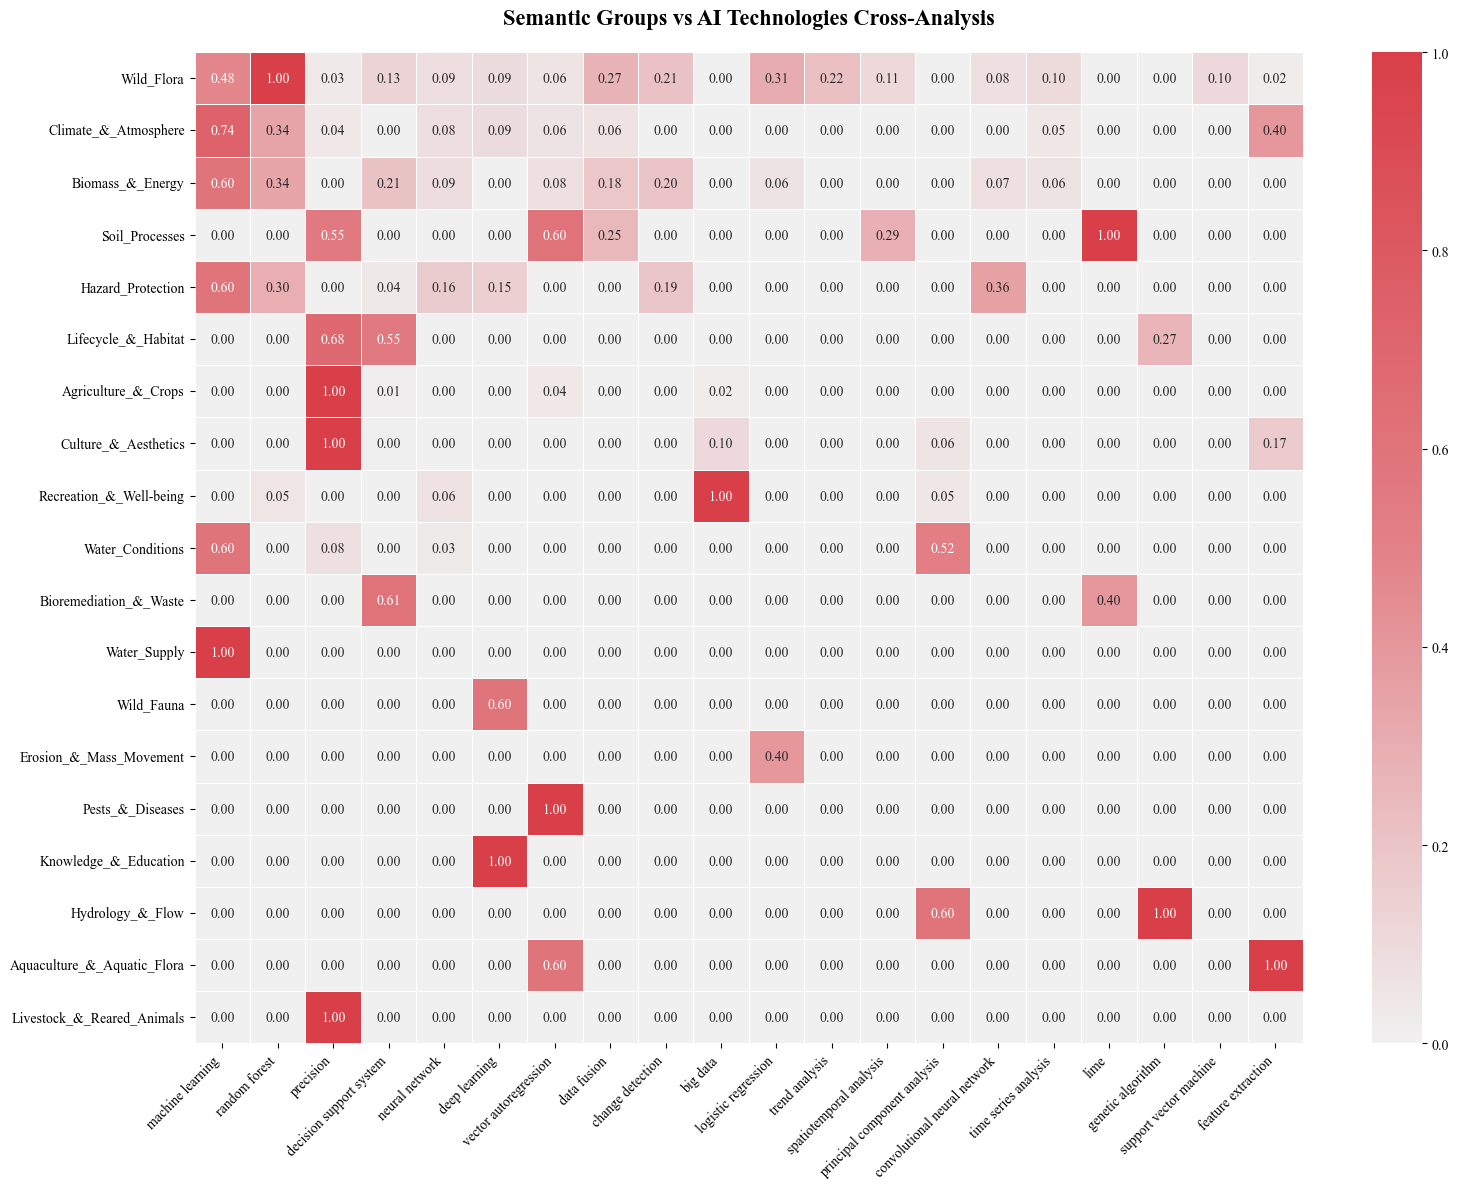

✅ Heatmap saved to: semantic_ai_heatmap_optimized.png

📑 Exporting all association results to an Excel appendix...
✅ Excel appendix successfully saved to: semantic_ai_full_associations_appendix.xlsx
   - Contains Semantic_to_AI data: 119 records
   - Contains AI_to_Semantic data: 119 records


In [9]:
import os
import re
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

class SemanticAIAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.all_articles = []
        self.articles = []

        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR",
            "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        self.ai_keyword_canonical_map = {
            "ml": "machine learning",
            "dl": "deep learning",
            "rl": "reinforcement learning",
            "ensemble methods": "ensemble learning",
            "artificial neural network": "neural network",
            "ann": "neural network",
            "dnn": "deep neural network",
            "cnn": "convolutional neural network",
            "rnn": "recurrent neural network",
            "lstm": "long short-term memory",
            "gru": "gated recurrent unit",
            "gnn": "graph neural network",
            "gcn": "graph convolutional network",
            "resnet": "residual network",
            "vit": "vision transformer",
            "mlp": "multilayer perceptron",
            "seq2seq": "sequence-to-sequence",
            "transformers": "transformer",
            "gan": "generative adversarial network",
            "vae": "variational autoencoder",
            "svm": "support vector machine",
            "svr": "support vector regression",
            "knn": "k-nearest neighbor",
            "gmm": "gaussian mixture model",
            "pca": "principal component analysis",
            "ica": "independent component analysis",
            "svd": "singular value decomposition",
            "t-sne": "t-distributed stochastic neighbor embedding",
            "umap": "uniform manifold approximation and projection",
            "gbdt": "gradient boosting decision tree",
            "mdp": "markov decision process",
            "td learning": "temporal difference learning",
            "dqn": "deep q-network",
            "actor-critic framework": "actor-critic",
            "sarsa": "state-action-reward-state-action",
            "ppo": "proximal policy optimization",
            "ddpg": "deep deterministic policy gradient",
            "sac": "soft actor-critic",
            "marl": "multi-agent reinforcement learning",
            "maddpg": "multi-agent deep deterministic policy gradient",
            "mappo": "multi-agent proximal policy optimization",
            "sift": "scale-invariant feature transform",
            "hog": "histogram of oriented gradients",
            "ocr": "optical character recognition",
            "you only look once": "yolo",
            "nlp": "natural language processing",
            "ner": "named entity recognition",
            "pos tagging": "part-of-speech tagging",
            "bow": "bag of words",
            "llm": "large language model",
            "sgd": "stochastic gradient descent",
            "adaptive moment estimation": "adam optimizer",
            "pso": "particle swarm optimization",
            "aco": "ant colony optimization",
            "arima": "autoregressive integrated moving average",
            "sarima": "seasonal arima",
            "var": "vector autoregression",
            "dtw": "dynamic time warping",
            "map estimation": "maximum a posteriori",
            "em algorithm": "expectation maximization",
            "mcmc": "markov chain monte carlo",
            "hmm": "hidden markov model",
            "hyperparameter tuning": "hyperparameter optimization",
            "roc": "roc curve",
            "outlier detection": "anomaly detection",
            "rule based system": "rule-based system",
            "dss": "decision support system",
            "cbr": "case-based reasoning",
            "xai": "explainable ai",
            "automl": "automated machine learning",
            "nas": "neural architecture search",
        }

        self.semantic_groups = {
            'Agriculture_&_Crops': ['crops', 'cereals', 'root crops', 'soft fruit', 'fodder', 'livestock feed', 'cultivated plants', 'plantations', 'agriculture', 'farming', 'harvest', 'orchard'],
            'Aquaculture_&_Aquatic_Flora': ['aquaculture', 'in-situ aquaculture', 'cultivated aquatic plants', 'algae', 'seaweed', 'marine plants'],
            'Livestock_&_Reared_Animals': ['reared animals', 'beef', 'dairy', 'animal products', 'livestock', 'cattle', 'poultry', 'sheep', 'pigs', 'pasture'],
            'Biomass_&_Energy': ['fibres', 'materials', 'energy source', 'bioenergy', 'fibres from animals', 'mechanical energy', 'biogas', 'wild plant materials', 'wild plant energy', 'wild animal nutrition', 'wild animal materials', 'biomass', 'biofuel', 'timber', 'wood'],
            'Wild_Flora': ['wild plants', 'terrestrial plants', 'aquatic plants', 'wild fungi', 'wild algae', 'flora', 'vegetation', 'forest', 'grassland', 'wetland plants'],
            'Wild_Fauna': ['wild animals', 'terrestrial animals', 'aquatic animals', 'fauna', 'wildlife', 'birds', 'mammals', 'fishes', 'insects', 'amphibians'],
            'Water_Supply': ['surface water', 'ground water', 'drinking water', 'non-drinking water', 'water supply', 'freshwater', 'reservoir', 'aquifer'],
            'Genetics_&_Breeding': ['seeds', 'spores', 'plant materials for breeding', 'new strains', 'varieties', 'individual genes', 'biological entities', 'animal genetic material', 'genetics', 'breeding', 'genomics', 'dna'],
            'Bioremediation_&_Waste': ['bio-remediation', 'micro-organisms', 'pollution degradation', 'filtration', 'sequestration', 'storage', 'accumulation', 'waste mediation', 'toxic substances', 'bioremediation', 'phytoremediation', 'waste treatment', 'water purification', 'pollution control'],
            'Sensory_Regulation': ['smell reduction', 'noise attenuation', 'visual screening', 'odor control', 'soundscape', 'acoustic regulation'],
            'Erosion_&_Mass_Movement': ['erosion control', 'water erosion', 'wind erosion', 'mass movement', 'landslides', 'erosion', 'soil erosion', 'coastal erosion', 'avalanche'],
            'Hydrology_&_Flow': ['hydrological cycle', 'water flow regulation', 'runoff', 'base flows', 'peak flows', 'hydrology', 'streamflow', 'flood control', 'drainage'],
            'Hazard_Protection': ['hazard mitigation', 'flood mitigation', 'surge protection', 'wind protection', 'fire protection', 'disaster risk reduction', 'storm surge', 'fire', 'wildfire'],
            'Lifecycle_&_Habitat': ['pollination', 'gamete dispersal', 'seed dispersal', 'nursery populations', 'breeding grounds', 'gene pool protection', 'genetic diversity conservation', 'population establishment', 'refuge habitats', 'feeding grounds', 'habitat', 'biodiversity', 'pollinators'],
            'Pests_&_Diseases': ['pest control', 'invasive species management', 'disease control', 'pest', 'disease', 'invasive species', 'biological control', 'pathogens'],
            'Soil_Processes': ['soil quality', 'weathering processes', 'decomposition', 'fixing processes', 'soil structure', 'biological agents', 'soil porosity', 'role of bacteria', 'role of fungi', 'soil', 'soil formation', 'nutrient cycling'],
            'Water_Conditions': ['water conditions', 'chemical condition', 'macronutrients', 'freshwater regulation', 'saltwater regulation', 'water quality', 'eutrophication'],
            'Climate_&_Atmosphere': ['atmospheric composition', 'oceanic circulation', 'climate change regulation', 'temperature regulation', 'humidity', 'ventilation', 'transpiration', 'microclimate', 'climate change', 'climate regulation', 'carbon sink', 'greenhouse gas'],
            'Recreation_&_Well-being': ['recreational activities', 'health promotion', 'recuperation', 'enjoyment', 'active interactions', 'immersive interactions', 'passive interactions', 'observational interactions', 'recreation', 'ecotourism', 'tourism', 'mental health', 'physical health'],
            'Knowledge_&_Education': ['scientific investigation', 'traditional ecological knowledge', 'education', 'training', 'environmental education', 'scientific research', 'indigenous knowledge'],
            'Culture_&_Aesthetics': ['culture', 'heritage', 'cultural resonance', 'aesthetic experiences', 'entertainment', 'representation outside setting', 'cultural heritage', 'landscape aesthetics', 'cultural identity'],
            'Spiritual_&_Symbolic': ['symbolic meaning', 'sense of place', 'distinctiveness', 'spiritual meaning', 'religious meaning', 'sacred landscapes', 'spiritual', 'religious', 'sacred groves'],
            'Conservation_&_Existence': ['contemporary existence', 'conservation importance', 'inter-generational existence', 'bequest value', 'intrinsic value of biodiversity', 'existence value', 'wildlife conservation']
        }
        
        self._initialize_semantic_groups()
        self._initialize_ai_canonical_groups()
        
    def _initialize_semantic_groups(self):
        """Flatten to obtain the base vocabulary collection"""
        self.all_cices_keywords = []
        for keywords_list in self.semantic_groups.values():
            self.all_cices_keywords.extend([kw.lower() for kw in keywords_list])
        self.all_cices_keywords = list(set(self.all_cices_keywords))


    def _initialize_ai_canonical_groups(self):
        """Group different spellings of the same AI keyword under one canonical form,
        and verify that the canonical keyword set fully covers the original vocabulary
        (no omissions and no new keywords)."""
        original_forms = {kw.lower() for kw in self.ai_keywords}

        self.ai_canonical_groups = defaultdict(list)
        for kw in self.ai_keywords:
            canon = self.ai_keyword_canonical_map.get(kw.lower(), kw.lower())
            self.ai_canonical_groups[canon].append(kw.lower())

        self.canonical_ai_keywords = sorted(self.ai_canonical_groups.keys())

        covered_spellings = {s for spellings in self.ai_canonical_groups.values() for s in spellings}
        missing = original_forms - covered_spellings
        extra = set(self.canonical_ai_keywords) - original_forms
        if missing:
            raise ValueError(f"Canonical mapping incomplete, missing keywords: {sorted(missing)}")
        if extra:
            raise ValueError(f"Canonical mapping introduces new keywords: {sorted(extra)}")

    def is_cices_match(self, article_keyword, cices_keyword):
        """
        [Relaxed matching logic] Substring inclusion matching (Substring Matching)
        """
        article_kw = article_keyword.lower().strip()
        cices_kw = cices_keyword.lower().strip()
        return cices_kw in article_kw

    def is_ai_match(self, search_text, ai_keyword):
        """
        [Keeps strict matching logic] Rigorous word boundary validation (Strict Word Boundary)
        """
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        
        if search_text == ai_kw:
            return True
        
        strict_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        
        if ai_kw in strict_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
        
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def generate_article_hash(self, article):
        parts = []
        if article.get('title'):
            parts.append(article['title'].lower().strip())
        if article.get('year'):
            parts.append(article['year'])
        if article.get('authors'):
            parts.append(article['authors'][0].lower().strip())
        return hashlib.md5('||'.join(parts).encode()).hexdigest()

    def read_literature_files(self):
        files = [f for f in os.listdir(self.data_directory) 
                if f.endswith('.txt') and 'download' in f]
        
        for file in sorted(files):
            try:
                with open(os.path.join(self.data_directory, file), 'r', 
                         encoding='utf-8', errors='ignore') as f:
                    self.parse_articles(f.read(), file)
            except Exception as e:
                print(f"⚠️ Failed to read {file}: {e}")

    def parse_articles(self, content, filename):
        for article_text in re.split(r'\nER\s*\n', content):
            if not article_text.strip():
                continue
            
            article = {
                'filename': filename,
                'keywords': set(),
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'authors': []
            }
            
            for pattern, field in [
                (r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', 'keywords_plus'),
                (r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', 'keywords')
            ]:
                match = re.search(pattern, article_text, re.DOTALL)
                if match:
                    keywords = self.extract_keywords(match.group(1))
                    article[field].update(keywords)
            
            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article['title'] = ti_match.group(1).replace('\n', ' ').strip()
            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article['year'] = py_match.group(1)
            else:
                ea_match = re.search(r'\nEA\s+.*?(\d{4})', article_text)
                if ea_match:
                    article['year'] = ea_match.group(1)
                else:
                    pd_match = re.search(r'\nPD\s+.*?(\d{4})', article_text)
                    if pd_match:
                        article['year'] = pd_match.group(1)
            
            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                article['authors'] = [a.strip() for a in au_match.group(1).split('\n') if a.strip()]
            
            if article['keywords'] or article['keywords_plus']:
                article['all_keywords'] = article['keywords'] | article['keywords_plus']
                self.articles.append(article)

    def extract_keywords(self, text):
        keywords = []
        for kw in re.split(r'[;\n]', text.replace('\n', ' ')):
            kw = re.sub(r'\s+', ' ', kw.strip().lower())
            kw = kw.strip('.,;()[]{}"\'-')
            if kw and len(kw) > 2:
                keywords.append(kw)
        return keywords

    def identify_semantic_ai_articles(self):
        """Identify combined articles (applying the high-recall relaxed matching strategy)"""
        combo_articles = []
        
        for article in self.articles:
            matched_semantic_groups = set()
            
            for group_name, group_keywords in self.semantic_groups.items():
                group_matched = False
                for kw in group_keywords:
                    for article_keyword in article['all_keywords']:
                        if self.is_cices_match(article_keyword, kw):
                            group_matched = True
                            break
                    if group_matched:
                        break 
                
                if group_matched:
                    matched_semantic_groups.add(group_name)
            
            matched_ai = []
            keywords_text = ' '.join(article['all_keywords'])
            # Match any spelling of a canonical group, then record ONLY the canonical keyword.
            for canon_kw, spellings in self.ai_canonical_groups.items():
                if any(self.is_ai_match(keywords_text, spelling) for spelling in spellings):
                    matched_ai.append(canon_kw)
            
            if matched_semantic_groups and matched_ai:
                article['matched_semantic_groups'] = list(matched_semantic_groups)
                article['matched_ai'] = matched_ai
                article['article_hash'] = self.generate_article_hash(article)
                combo_articles.append(article)

        unique_articles = []
        seen_hashes = set()
        for article in combo_articles:
            if article['article_hash'] not in seen_hashes:
                seen_hashes.add(article['article_hash'])
                unique_articles.append(article)

        return unique_articles

    def analyze_combinations(self, combo_articles):
        """Count co-occurrence relationships"""
        cooccurrence = defaultdict(lambda: defaultdict(int))
        all_semantic_counts = Counter()
        all_ai_counts = Counter()
        combo_semantic_counts = Counter()
        combo_ai_counts = Counter()
        
        for article in self.articles:
            matched_groups = set()
            for group_name, group_keywords in self.semantic_groups.items():
                group_matched = False
                for kw in group_keywords:
                    for article_keyword in article['all_keywords']:
                        if self.is_cices_match(article_keyword, kw):
                            group_matched = True
                            break
                    if group_matched:
                        break
                if group_matched:
                    matched_groups.add(group_name)
            
            for group in matched_groups:
                all_semantic_counts[group] += 1
            
            keywords_text = ' '.join(article['all_keywords'])
            matched_ai = set()
            # Match any spelling of a canonical group, then count ONLY the canonical keyword.
            for canon_kw, spellings in self.ai_canonical_groups.items():
                if any(self.is_ai_match(keywords_text, spelling) for spelling in spellings):
                    matched_ai.add(canon_kw)
            for ai_kw in matched_ai:
                all_ai_counts[ai_kw] += 1
        
        for article in combo_articles:
            for group in article['matched_semantic_groups']:
                combo_semantic_counts[group] += 1
                for ai_kw in set(article['matched_ai']):
                    cooccurrence[group][ai_kw] += 1
            for ai_kw in set(article['matched_ai']):
                combo_ai_counts[ai_kw] += 1
        
        return cooccurrence, all_semantic_counts, all_ai_counts, combo_semantic_counts, combo_ai_counts

    def calculate_association_metrics(self, cooccurrence, all_sem_cnt, all_ai_cnt, 
                                     combo_sem_cnt, combo_ai_cnt, total_combo, total_arts, min_cooc=2):
        print(f"📊 Calculating association metrics (co-occurrence ≥ {min_cooc}, lift ≥ 1.0)")
        
        semantic_to_ai_results = []
        for sem_group in combo_sem_cnt:
            ai_combinations = []
            for ai_kw, cooccur_count in cooccurrence[sem_group].items():
                if cooccur_count >= min_cooc:
                    support = cooccur_count / total_combo
                    confidence = cooccur_count / all_sem_cnt[sem_group]
                    ai_prob = all_ai_cnt[ai_kw] / total_arts
                    lift = confidence / ai_prob if ai_prob > 0 else 0
                    
                    if lift >= 1.0:
                        ai_combinations.append({
                            'AI_Keyword': ai_kw, 'Cooccurrence': cooccur_count,
                            'Confidence': round(confidence, 4), 'Lift': round(lift, 4), 'Support': round(support, 4)
                        })
            
            if ai_combinations:
                semantic_to_ai_results.append({
                    'Semantic_Group': sem_group,
                    'Keywords_Count': len(self.semantic_groups[sem_group]),
                    'Group_Freq_Combo': combo_sem_cnt[sem_group],
                    'Group_Freq_All': all_sem_cnt[sem_group],
                    'AI_Combinations': sorted(ai_combinations, key=lambda x: x['Cooccurrence'], reverse=True)
                })
        
        ai_to_semantic_results = []
        for ai_kw in combo_ai_cnt:
            sem_combinations = []
            for sem_group in combo_sem_cnt:
                cooccur_count = cooccurrence[sem_group][ai_kw]
                if cooccur_count >= min_cooc:
                    support = cooccur_count / total_combo
                    confidence = cooccur_count / all_ai_cnt[ai_kw]
                    sem_prob = all_sem_cnt[sem_group] / total_arts
                    lift = confidence / sem_prob if sem_prob > 0 else 0
                    
                    if lift >= 1.0:
                        sem_combinations.append({
                            'Semantic_Group': sem_group, 'Cooccurrence': cooccur_count,
                            'Confidence': round(confidence, 4), 'Lift': round(lift, 4), 'Support': round(support, 4)
                        })
            
            if sem_combinations:
                ai_to_semantic_results.append({
                    'AI_Keyword': ai_kw, 'AI_Freq_Combo': combo_ai_cnt[ai_kw], 'AI_Freq_All': all_ai_cnt[ai_kw],
                    'Semantic_Combinations': sorted(sem_combinations, key=lambda x: x['Cooccurrence'], reverse=True)
                })
        
        return semantic_to_ai_results, ai_to_semantic_results

    def _score_associations(self, associations):
        if not associations: return []
        
        confidences = [a['Confidence'] for a in associations]
        lifts = [a['Lift'] for a in associations]
        cooccurrences = [a['Cooccurrence'] for a in associations]
        
        def normalize(values):
            if len(values) <= 1 or max(values) == min(values): return [1.0] * len(values)
            return [(v - min(values)) / (max(values) - min(values)) for v in values]
        
        norm_conf, norm_lift, norm_cooc = normalize(confidences), normalize(lifts), normalize(cooccurrences)
        
        scored_associations = []
        for i, assoc in enumerate(associations):
            score = 0.4 * norm_conf[i] + 0.4 * norm_lift[i] + 0.2 * norm_cooc[i]
            scored_assoc = assoc.copy()
            scored_assoc['Composite_Score'] = round(score, 4)
            scored_associations.append(scored_assoc)
        
        scored_associations.sort(key=lambda x: x['Composite_Score'], reverse=True)
        return scored_associations

    def generate_detailed_report(self, sem_to_ai, ai_to_sem, combo_arts):
        print("\n" + "="*80)
        print("Interdisciplinary In-depth Cross Analysis: Domain Semantic Groups → AI Technologies")
        print("="*80)
        
        print(f"\n📌 I. Semantic Group → AI Association Analysis (Global Top 30)")
        print("-" * 80)
        all_sem_assocs = []
        for res in sem_to_ai:
            for assoc in res['AI_Combinations']:
                copy_assoc = assoc.copy()
                copy_assoc['Semantic_Group'] = res['Semantic_Group']
                all_sem_assocs.append(copy_assoc)
        
        all_sem_assocs.sort(key=lambda x: x.get('Composite_Score', 0), reverse=True)
        print(f"{'Rank':<4} {'Semantic Group':<30} {'AI Technology':<25} {'Composite Score':<8} {'Co-occ':<6}")
        print("-" * 80)
        for i, a in enumerate(all_sem_assocs[:30], 1):
            print(f"{i:<4} {a['Semantic_Group'][:28]:<30} {a['AI_Keyword'][:23]:<25} {a.get('Composite_Score',0):<8.3f} {a['Cooccurrence']:<6}")

        print(f"\n📌 II. AI → Semantic Group Association Analysis (Global Top 30)")
        print("-" * 80)
        all_ai_assocs = []
        for res in ai_to_sem:
            for assoc in res['Semantic_Combinations']:
                copy_assoc = assoc.copy()
                copy_assoc['AI_Keyword'] = res['AI_Keyword']
                all_ai_assocs.append(copy_assoc)
                
        all_ai_assocs.sort(key=lambda x: x.get('Composite_Score', 0), reverse=True)
        print(f"{'Rank':<4} {'AI Technology':<25} {'Semantic Group':<30} {'Composite Score':<8} {'Co-occ':<6}")
        print("-" * 80)
        for i, a in enumerate(all_ai_assocs[:30], 1):
            print(f"{i:<4} {a['AI_Keyword'][:23]:<25} {a['Semantic_Group'][:28]:<30} {a.get('Composite_Score',0):<8.3f} {a['Cooccurrence']:<6}")

    def plot_heatmap(self, sem_to_ai, ai_to_sem, top_n=20):
        print("\n" + "="*80)
        print("📈 Plotting semantic group - AI association heatmap...")
        print("="*80)
        
        semantic_freq = defaultdict(int)
        ai_freq = defaultdict(int)
        
        for r in sem_to_ai:
            for a in r['AI_Combinations']:
                semantic_freq[r['Semantic_Group']] += a['Cooccurrence']
                ai_freq[a['AI_Keyword']] += a['Cooccurrence']
                
        top_semantic = [k for k, v in sorted(semantic_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]]
        top_ai = [k for k, v in sorted(ai_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]]
        
        if not top_semantic or not top_ai: return None
        
        heatmap_data = np.zeros((len(top_semantic), len(top_ai)))
        
        for r in sem_to_ai:
            if r['Semantic_Group'] in top_semantic:
                row_idx = top_semantic.index(r['Semantic_Group'])
                for a in r['AI_Combinations']:
                    if a['AI_Keyword'] in top_ai:
                        heatmap_data[row_idx, top_ai.index(a['AI_Keyword'])] = a.get('Composite_Score', 0)
                        
        heatmap_df = pd.DataFrame(heatmap_data, index=top_semantic, columns=top_ai)
        
        plt.figure(figsize=(16, 12))
        cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#f0f0f0', '#E28187', '#D93F49'])
        ax = sns.heatmap(heatmap_df, cmap=cmap, annot=True, fmt='.2f', linewidths=0.5, linecolor='white')
        
        plt.title('Semantic Groups vs AI Technologies Cross-Analysis', fontsize=16, fontweight='bold', pad=20)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
        plt.tight_layout()
        plt.savefig('semantic_ai_heatmap_optimized.png', dpi=600, bbox_inches='tight')
        plt.show()
        print("✅ Heatmap saved to: semantic_ai_heatmap_optimized.png")

    def export_all_associations_to_excel(self, sem_to_ai, ai_to_sem, output_filename="semantic_ai_full_associations_appendix.xlsx"):
        """Export the results of all association analyses to an Excel file as a research appendix"""
        print("\n" + "="*80)
        print("📑 Exporting all association results to an Excel appendix...")
        print("="*80)
        
        # 1. Flatten the Semantic -> AI data
        sem_ai_data = []
        for res in sem_to_ai:
            sem_group = res['Semantic_Group']
            for assoc in res['AI_Combinations']:
                sem_ai_data.append({
                    'Semantic_Group': sem_group,
                    'AI_Keyword': assoc['AI_Keyword'],
                    'Cooccurrence': assoc['Cooccurrence'],
                    'Support': assoc.get('Support', 0),
                    'Confidence': assoc.get('Confidence', 0),
                    'Lift': assoc.get('Lift', 0),
                    'Composite_Score': assoc.get('Composite_Score', 0)
                })
        
        df_sem_ai = pd.DataFrame(sem_ai_data)
        if not df_sem_ai.empty:
            df_sem_ai = df_sem_ai.sort_values(by=['Semantic_Group', 'Composite_Score'], ascending=[True, False])

        ai_sem_data = []
        for res in ai_to_sem:
            ai_kw = res['AI_Keyword']
            for assoc in res['Semantic_Combinations']:
                ai_sem_data.append({
                    'AI_Keyword': ai_kw,
                    'Semantic_Group': assoc['Semantic_Group'],
                    'Cooccurrence': assoc['Cooccurrence'],
                    'Support': assoc.get('Support', 0),
                    'Confidence': assoc.get('Confidence', 0),
                    'Lift': assoc.get('Lift', 0),
                    'Composite_Score': assoc.get('Composite_Score', 0)
                })
                
        df_ai_sem = pd.DataFrame(ai_sem_data)
        if not df_ai_sem.empty:
            df_ai_sem = df_ai_sem.sort_values(by=['AI_Keyword', 'Composite_Score'], ascending=[True, False])

        try:
            with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
                if not df_sem_ai.empty:
                    df_sem_ai.to_excel(writer, sheet_name='Semantic_to_AI_Full', index=False)
                if not df_ai_sem.empty:
                    df_ai_sem.to_excel(writer, sheet_name='AI_to_Semantic_Full', index=False)
            print(f"✅ Excel appendix successfully saved to: {output_filename}")
            print(f"   - Contains Semantic_to_AI data: {len(df_sem_ai)} records")
            print(f"   - Contains AI_to_Semantic data: {len(df_ai_sem)} records")
        except Exception as e:
            print(f"⚠️ Error saving Excel: {e}")

    def run_analysis(self, min_cooccurrence=2):
        print("🚀 Starting execution: Advanced cross-analysis engine (high-recall substring matching version)...")

        self.read_literature_files()
        if not self.articles: return

        combo_articles = self.identify_semantic_ai_articles()
        if not combo_articles: return

        cooc, all_sem, all_ai, combo_sem, combo_ai = self.analyze_combinations(combo_articles)

        sem_to_ai, ai_to_sem = self.calculate_association_metrics(
            cooc, all_sem, all_ai, combo_sem, combo_ai, len(combo_articles), len(self.articles), min_cooccurrence)
        
        for res in sem_to_ai: res['AI_Combinations'] = self._score_associations(res['AI_Combinations'])
        for res in ai_to_sem: res['Semantic_Combinations'] = self._score_associations(res['Semantic_Combinations'])

        self.generate_detailed_report(sem_to_ai, ai_to_sem, combo_articles)

        self.plot_heatmap(sem_to_ai, ai_to_sem, top_n=20)

        self.export_all_associations_to_excel(sem_to_ai, ai_to_sem)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = SemanticAIAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_analysis(min_cooccurrence=3)

WEIGHT SENSITIVITY ANALYSIS (B): multi-scheme comparison & selection
📊 Calculating association metrics (co-occurrence ≥ 3, lift ≥ 1.0)

Evaluating 20 weight schemes on the simplex (step=0.1).

All weight schemes ranked by representativeness/robustness (higher = ranking best summarizes the whole family):
 Rank  w_appearance  w_confidence  w_lift  is_baseline  Mean_rho_vs_others  Mean_tau_vs_others  Rho_vs_baseline  Robustness_score
    1         0.500         0.200   0.300        False              0.9847              0.9447           1.0000            0.9647
    2         0.100         0.500   0.400        False              0.9847              0.9447           1.0000            0.9647
    3         0.200         0.300   0.500        False              0.9847              0.9447           1.0000            0.9647
    4         0.200         0.400   0.400         True              0.9847              0.9447           1.0000            0.9647
    5         0.300         0.300   0.400    

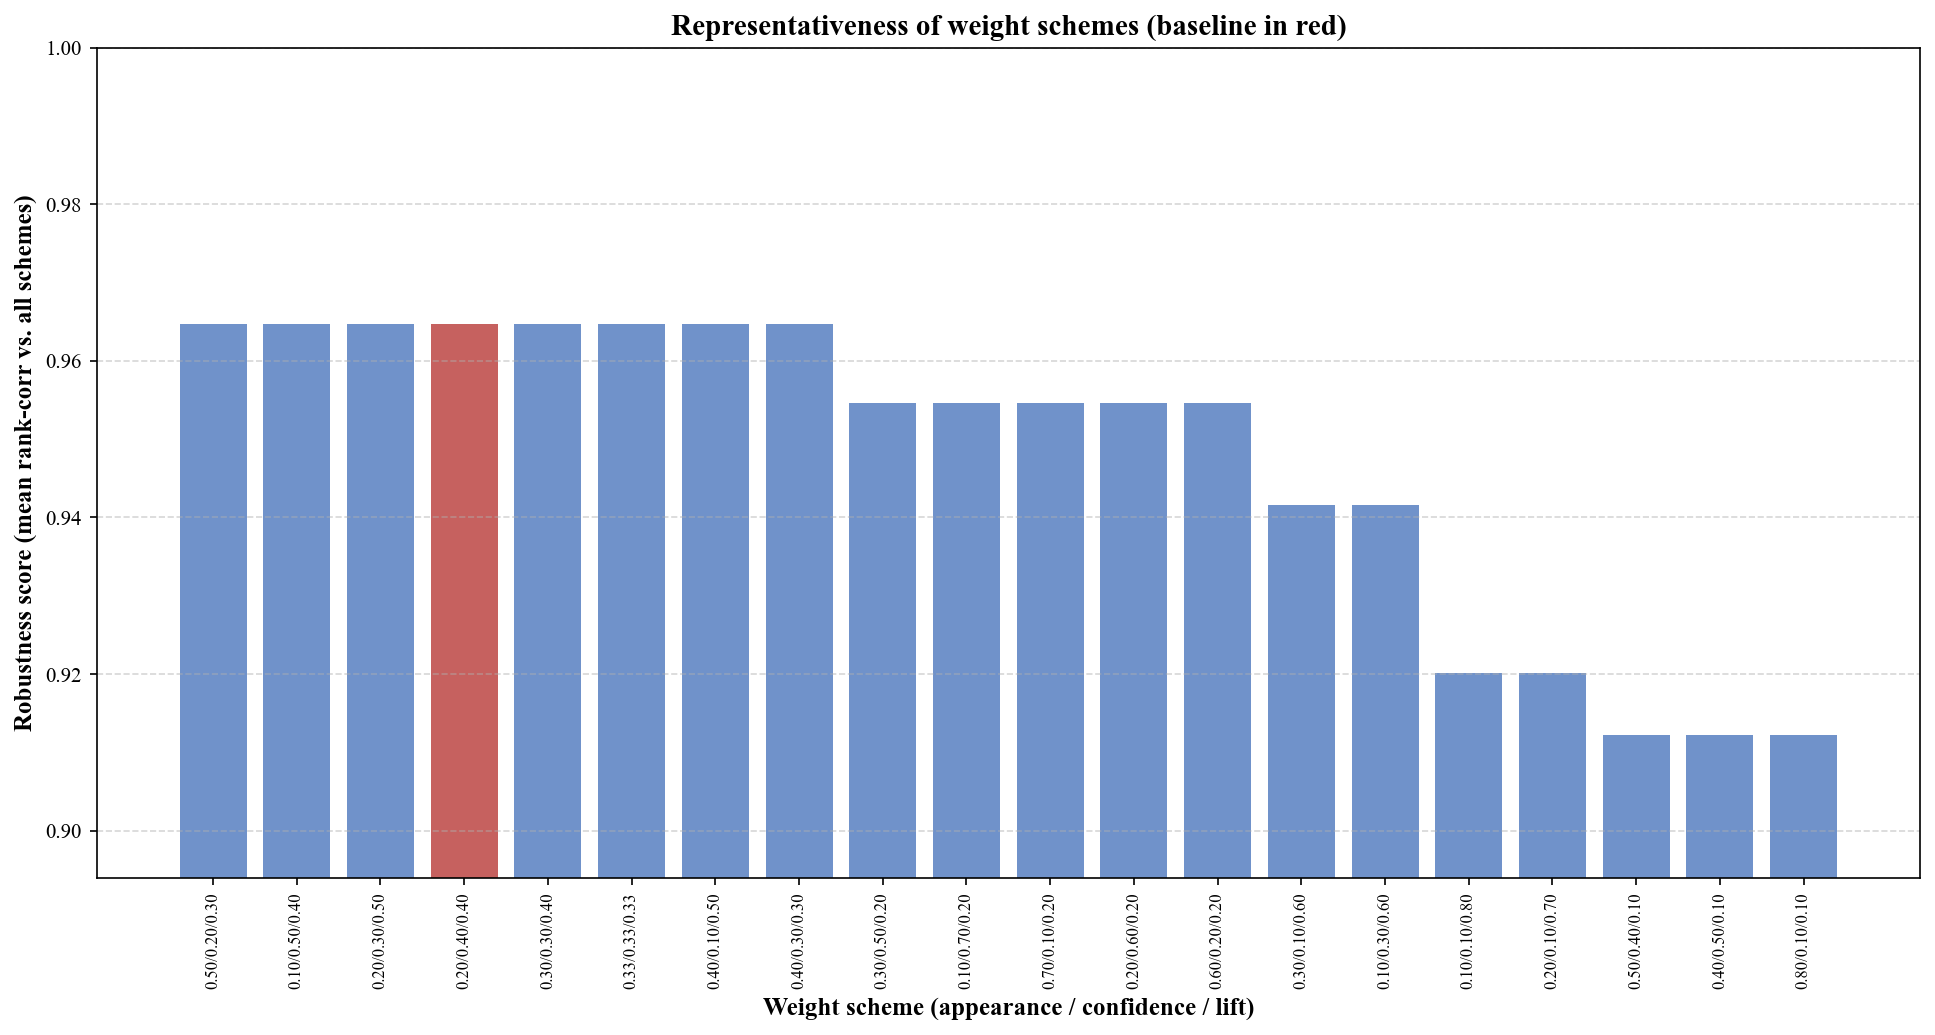


✅ Saved: weight_sensitivity_analysis_B.xlsx
✅ Saved: weight_sensitivity_B.pdf


In [5]:
import numpy as np
import pandas as pd
from itertools import product
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

BASELINE = (0.2, 0.4, 0.4)


def build_weight_grid(step=0.1, include=None):
    """Enumerate all (w1,w2,w3) on the simplex at the given step (>0 each,
    summing to 1). With step=0.1 this yields 36 lattice schemes; we then
    ensure the baseline and equal weights are present and, if a target
    count is requested, thin the grid down to a representative subset."""
    grid = []
    ticks = [round(i * step, 10) for i in range(1, int(round(1 / step)))]  # exclude 0 and 1
    for w1, w2 in product(ticks, ticks):
        w3 = round(1 - w1 - w2, 10)
        if w3 > 0 and abs(w1 + w2 + w3 - 1) < 1e-9:
            grid.append((round(w1, 3), round(w2, 3), round(w3, 3)))
    for w in (BASELINE, (1/3, 1/3, 1/3)):
        w = tuple(round(x, 3) for x in w)
        if w not in grid:
            grid.append(w)
    if include:
        for w in include:
            w = tuple(round(x, 3) for x in w)
            if w not in grid:
                grid.append(w)
    return sorted(set(grid))


def select_representative_subset(grid, n_target=20):
    """If the grid has more than n_target schemes, keep a spread-out subset
    that always retains the baseline and equal weights and samples the rest
    as evenly as possible over the simplex."""
    must_keep = [tuple(round(x, 3) for x in BASELINE),
                 tuple(round(x, 3) for x in (1/3, 1/3, 1/3))]
    must_keep = [w for w in must_keep if w in grid]
    remaining = [w for w in grid if w not in must_keep]
    if len(remaining) + len(must_keep) <= n_target:
        return sorted(set(must_keep + remaining))
    k = n_target - len(must_keep)
    idx = np.linspace(0, len(remaining) - 1, k).round().astype(int)
    subset = must_keep + [remaining[i] for i in idx]
    return sorted(set(subset))


def run_weight_sensitivity_B(analyzer=None, sem_to_ai=None,
                             data_directory="./annotated_wos_data",
                             min_cooccurrence=3, n_schemes=20):
    print("=" * 80)
    print("WEIGHT SENSITIVITY ANALYSIS (B): multi-scheme comparison & selection")
    print("=" * 80)

    if sem_to_ai is None:
        if analyzer is None:
            analyzer = SemanticAIAnalyzer(data_directory=data_directory)  # noqa: F821
            analyzer.read_literature_files()
        combo = analyzer.identify_semantic_ai_articles()
        cooc, all_sem, all_ai, cs, ca = analyzer.analyze_combinations(combo)
        sem_to_ai, _ = analyzer.calculate_association_metrics(
            cooc, all_sem, all_ai, cs, ca, len(combo), len(analyzer.articles), min_cooccurrence)

    # Build ~n_schemes weight schemes spanning the simplex.
    grid = build_weight_grid(step=0.1)
    schemes = select_representative_subset(grid, n_target=n_schemes)
    print(f"\nEvaluating {len(schemes)} weight schemes on the simplex (step=0.1).")

    rankings = {}
    for w in schemes:
        rankings[w] = ranking_from_scores(score_semantic_to_ai(sem_to_ai, w))  # noqa: F821
    keys = list(next(iter(rankings.values())).keys())

    base = tuple(round(x, 3) for x in BASELINE)
    base_vec = [rankings[base][k] for k in keys]

    rows = []
    for w in schemes:
        vw = [rankings[w][k] for k in keys]
        rho_others, tau_others = [], []
        for u in schemes:
            if u == w:
                continue
            vu = [rankings[u][k] for k in keys]
            rho_others.append(spearmanr(vw, vu).correlation)
            tau_others.append(kendalltau(vw, vu).correlation)
        rho_base = spearmanr(vw, base_vec).correlation
        rows.append({
            'w_appearance': w[0], 'w_confidence': w[1], 'w_lift': w[2],
            'is_baseline': (w == base),
            'Mean_rho_vs_others': round(float(np.mean(rho_others)), 4),
            'Mean_tau_vs_others': round(float(np.mean(tau_others)), 4),
            'Rho_vs_baseline': round(float(rho_base), 4),
        })

    df = pd.DataFrame(rows)
    df['Robustness_score'] = ((df['Mean_rho_vs_others'] + df['Mean_tau_vs_others']) / 2).round(4)
    df = df.sort_values('Robustness_score', ascending=False).reset_index(drop=True)
    df.insert(0, 'Rank', df.index + 1)

    print("\nAll weight schemes ranked by representativeness/robustness "
          "(higher = ranking best summarizes the whole family):")
    with pd.option_context('display.max_rows', None, 'display.width', 160):
        print(df.to_string(index=False))

    best = df.iloc[0]
    base_row = df[df['is_baseline']].iloc[0]
    print("\n" + "-" * 80)
    print(f"→ Most representative scheme: "
          f"({best['w_appearance']}, {best['w_confidence']}, {best['w_lift']}) "
          f"with robustness score {best['Robustness_score']:.4f} (rank #{int(best['Rank'])}).")
    print(f"→ Baseline (0.2/0.4/0.4): robustness score {base_row['Robustness_score']:.4f} "
          f"(rank #{int(base_row['Rank'])} of {len(df)}), "
          f"ρ vs. most-representative scheme = "
          f"{spearmanr([rankings[base][k] for k in keys], [rankings[(best['w_appearance'], best['w_confidence'], best['w_lift'])][k] for k in keys]).correlation:.4f}.")

    top_score = best['Robustness_score']
    base_score = base_row['Robustness_score']
    if best['is_baseline']:
        verdict = ("The baseline 0.2/0.4/0.4 weighting is itself the most representative "
                   "scheme, and is therefore retained for all subsequent analyses.")
    elif top_score - base_score <= 0.02:
        verdict = ("The baseline 0.2/0.4/0.4 weighting is statistically indistinguishable "
                   "from the most representative scheme (Δrobustness ≤ 0.02 and near-unit "
                   "rank correlation); it emphasises confidence and lift as intended and is "
                   "retained for all subsequent analyses.")
    else:
        verdict = ("The most representative scheme differs marginally from the baseline; "
                   "because the substantive ranking is preserved (high ρ), the baseline "
                   "0.2/0.4/0.4 weighting is retained for interpretability and consistency "
                   "with the manuscript, and the difference does not affect the conclusions.")
    print("\n[Recommendation] " + verdict)
    print("-" * 80)

    fig, ax = plt.subplots(figsize=(13, 7), dpi=150)
    labels = [f"{r.w_appearance:.2f}/{r.w_confidence:.2f}/{r.w_lift:.2f}" for r in df.itertuples()]
    colors = ['#C0504D' if r.is_baseline else '#6086C5' for r in df.itertuples()]
    ax.bar(range(len(df)), df['Robustness_score'], color=colors, alpha=0.9)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_ylabel("Robustness score (mean rank-corr vs. all schemes)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Weight scheme (appearance / confidence / lift)", fontsize=12, fontweight='bold')
    ax.set_title("Representativeness of weight schemes (baseline in red)", fontsize=14, fontweight='bold')
    ax.set_ylim(min(df['Robustness_score']) * 0.98, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('weight_sensitivity_B.pdf', dpi=1200, bbox_inches='tight')
    plt.show()

    with pd.ExcelWriter('weight_sensitivity_analysis_B.xlsx', engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Scheme_Ranking', index=False)
    print("\n✅ Saved: weight_sensitivity_analysis_B.xlsx")
    print("✅ Saved: weight_sensitivity_B.pdf")
    return df


if __name__ == "__main__":
    run_weight_sensitivity_B(data_directory=r"./annotated_wos_data", min_cooccurrence=3)


In [7]:
import os
import re
import pandas as pd
from collections import defaultdict

class GeographyBibliometricAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.articles = []

        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR", "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        self.ai_keyword_canonical_map = {
            "ml": "machine learning",
            "dl": "deep learning",
            "rl": "reinforcement learning",
            "ensemble methods": "ensemble learning",
            "artificial neural network": "neural network",
            "ann": "neural network",
            "dnn": "deep neural network",
            "cnn": "convolutional neural network",
            "rnn": "recurrent neural network",
            "lstm": "long short-term memory",
            "gru": "gated recurrent unit",
            "gnn": "graph neural network",
            "gcn": "graph convolutional network",
            "resnet": "residual network",
            "vit": "vision transformer",
            "mlp": "multilayer perceptron",
            "seq2seq": "sequence-to-sequence",
            "transformers": "transformer",
            "gan": "generative adversarial network",
            "vae": "variational autoencoder",
            "svm": "support vector machine",
            "svr": "support vector regression",
            "knn": "k-nearest neighbor",
            "gmm": "gaussian mixture model",
            "pca": "principal component analysis",
            "ica": "independent component analysis",
            "svd": "singular value decomposition",
            "t-sne": "t-distributed stochastic neighbor embedding",
            "umap": "uniform manifold approximation and projection",
            "gbdt": "gradient boosting decision tree",
            "mdp": "markov decision process",
            "td learning": "temporal difference learning",
            "dqn": "deep q-network",
            "actor-critic framework": "actor-critic",
            "sarsa": "state-action-reward-state-action",
            "ppo": "proximal policy optimization",
            "ddpg": "deep deterministic policy gradient",
            "sac": "soft actor-critic",
            "marl": "multi-agent reinforcement learning",
            "maddpg": "multi-agent deep deterministic policy gradient",
            "mappo": "multi-agent proximal policy optimization",
            "sift": "scale-invariant feature transform",
            "hog": "histogram of oriented gradients",
            "ocr": "optical character recognition",
            "you only look once": "yolo",
            "nlp": "natural language processing",
            "ner": "named entity recognition",
            "pos tagging": "part-of-speech tagging",
            "bow": "bag of words",
            "llm": "large language model",
            "sgd": "stochastic gradient descent",
            "adaptive moment estimation": "adam optimizer",
            "pso": "particle swarm optimization",
            "aco": "ant colony optimization",
            "arima": "autoregressive integrated moving average",
            "sarima": "seasonal arima",
            "var": "vector autoregression",
            "dtw": "dynamic time warping",
            "map estimation": "maximum a posteriori",
            "em algorithm": "expectation maximization",
            "mcmc": "markov chain monte carlo",
            "hmm": "hidden markov model",
            "hyperparameter tuning": "hyperparameter optimization",
            "roc": "roc curve",
            "outlier detection": "anomaly detection",
            "rule based system": "rule-based system",
            "dss": "decision support system",
            "cbr": "case-based reasoning",
            "xai": "explainable ai",
            "automl": "automated machine learning",
            "nas": "neural architecture search",
        }
        self._initialize_ai_canonical_groups()

    def _initialize_ai_canonical_groups(self):
        """Group spellings of the same AI keyword under one canonical form and
        verify full coverage (same verification as the reference code)."""
        original_forms = {kw.lower() for kw in self.ai_keywords}
        self.ai_canonical_groups = defaultdict(list)
        for kw in self.ai_keywords:
            canon = self.ai_keyword_canonical_map.get(kw.lower(), kw.lower())
            self.ai_canonical_groups[canon].append(kw.lower())
        self.canonical_ai_keywords = sorted(self.ai_canonical_groups.keys())

        covered_spellings = {s for spellings in self.ai_canonical_groups.values() for s in spellings}
        missing = original_forms - covered_spellings
        extra = set(self.canonical_ai_keywords) - original_forms
        if missing:
            raise ValueError(f"Canonical mapping incomplete, missing keywords: {sorted(missing)}")
        if extra:
            raise ValueError(f"Canonical mapping introduces new keywords: {sorted(extra)}")

    def is_ai_match(self, search_text, ai_keyword):
        """严格词边界 AI 匹配逻辑"""
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        if search_text == ai_kw: return True
        strict_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        if ai_kw in strict_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
            
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def extract_keywords(self, text):
        """Parse and normalize DE/ID keyword fields (same as the reference code)."""
        keywords = []
        for kw in re.split(r'[;\n]', text.replace('\n', ' ')):
            kw = re.sub(r'\s+', ' ', kw.strip().lower())
            kw = kw.strip('.,;()[]{}"\'-')
            if kw and len(kw) > 2:
                keywords.append(kw)
        return keywords

    def extract_countries(self, c1_text):
        """
        基于你提出的极简法则：提取最后一个逗号与句号之间的内容。
        使用 set() 完美解决同一篇文章中同一国家多次出现的问题。
        """
        countries = set()

        lines = c1_text.strip().split('\n')
        
        for line in lines:
            line = line.strip()
            if not line:
                continue

            last_comma_idx = line.rfind(',')
            if last_comma_idx != -1:
                raw_country = line[last_comma_idx + 1:].strip(' .\r\n')
                upper_country = raw_country.upper()
                if "USA" in upper_country or "UNITED STATES" in upper_country:
                    standard_country = "USA"
                elif "CHINA" in upper_country or "PEOPLES R CHINA" in upper_country:
                    standard_country = "China"
                elif any(uk_part in upper_country for uk_part in ["ENGLAND", "SCOTLAND", "WALES", "NORTH IRELAND", "UNITED KINGDOM", "UK"]):
                    standard_country = "UK"
                elif "RUSSIA" in upper_country or "RUSSIAN FEDERATION" in upper_country:
                    standard_country = "Russia"
                elif "SOUTH KOREA" in upper_country:
                    standard_country = "South Korea"
                elif "TAIWAN" in upper_country:
                    standard_country = "Taiwan"
                else:
                    standard_country = re.sub(r'[^a-zA-Z\s]', '', raw_country).strip().title()
                if len(standard_country) >= 2:
                    countries.add(standard_country)
                    
        return countries

    def run_geographical_statistics(self):
        print(f"🚀 开始统计全球国家发文及引用情况...")
        country_stats = defaultdict(lambda: {
            'Total_Articles': 0, 
            'Provisioning': 0, 
            'Regulating': 0, 
            'Cultural': 0, 
            'AI_Methods': 0, 
            'Total_Citations': 0
        })

        files = [f for f in os.listdir(self.data_directory) if f.endswith('.txt') and 'download' in f]
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    records = re.split(r'\nER\s*\n', content)
                    
                    for record in records:
                        if not record.strip() or not re.search(r'(^|\n)PT\s+', record): 
                            continue
                        c1_match = re.search(r'\nC1\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', record, re.DOTALL)
                        if not c1_match:
                            continue
                        countries = self.extract_countries(c1_match.group(1))
                        
                        if not countries:
                            continue
                        cg_matches = re.findall(r'\nCG\s+([^\n]+)', record)
                        categories = [m.strip().capitalize() for m in cg_matches]
                        tc_match = re.search(r'\nTC\s+(\d+)', record)
                        citations = int(tc_match.group(1)) if tc_match else 0

                        is_ai = False
                        keywords = set()
                        id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', record, re.DOTALL)
                        if id_match:
                            keywords.update(self.extract_keywords(id_match.group(1)))
                        de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', record, re.DOTALL)
                        if de_match:
                            keywords.update(self.extract_keywords(de_match.group(1)))
                        keywords_text = ' '.join(keywords)
                        if keywords_text:
                            for canon_kw, spellings in self.ai_canonical_groups.items():
                                if any(self.is_ai_match(keywords_text, sp) for sp in spellings):
                                    is_ai = True
                                    break

                        for country in countries:
                            country_stats[country]['Total_Articles'] += 1
                            country_stats[country]['Total_Citations'] += citations

                            for category in categories:
                                if category == 'Provisioning':
                                    country_stats[country]['Provisioning'] += 1
                                elif category == 'Regulating':
                                    country_stats[country]['Regulating'] += 1
                                elif category == 'Cultural':
                                    country_stats[country]['Cultural'] += 1
                                
                            if is_ai:
                                country_stats[country]['AI_Methods'] += 1
            except Exception as e:
                print(f"❌ 读取文件 {file} 时出错: {e}")

        df_final = pd.DataFrame.from_dict(country_stats, orient='index').reset_index()
        df_final.rename(columns={'index': 'Country'}, inplace=True)

        df_final.sort_values(by='Total_Articles', ascending=False, inplace=True)

        output_file = 'global_country_bibliometric_stats.xlsx'
        df_final.to_excel(output_file, index=False)
        
        print("\n" + "="*60)
        print(f"✅ 极简提取统计完成！结果已成功保存至: {output_file}")
        print(f"📊 识别并提取的有效发文国家/地区总数: {len(df_final)}")
        print("="*60)
        print("\n🏆 全球发文量 Top 10 国家概览:")
        print(df_final.head(10).to_string(index=False))
        
        return df_final

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = GeographyBibliometricAnalyzer(data_directory=TARGET_DIR)
    stats_df = analyzer.run_geographical_statistics()

🚀 开始统计全球国家发文及引用情况...

✅ 极简提取统计完成！结果已成功保存至: global_country_bibliometric_stats.xlsx
📊 识别并提取的有效发文国家/地区总数: 2455

🏆 全球发文量 Top 10 国家概览:
  Country  Total_Articles  Provisioning  Regulating  Cultural  AI_Methods  Total_Citations
    China           14906          2572       11742       592         658           437088
      USA           11830          2470        8513       847         326           445024
       UK            5211          1126        3519       566         118           232682
  Germany            4470           904        3184       382         133           188440
Australia            3978           893        2730       355          81           180066
    Spain            3296           721        2264       311          98           119406
   Canada            3260           857        2201       202          91           123941
   France            3067           791        2086       190          81           123605
    Italy            2884           591        2017

In [9]:
import pandas as pd
import re

def clean_bibliometric_country_data(input_file, output_file):
    print(f"🚀 Starting to clean data file: {input_file}")

    df = pd.read_excel(input_file)

    valid_countries = {
        'AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA',
        'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN',
        'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BHUTAN',
        'BOLIVIA', 'BOSNIA AND HERZEGOVINA', 'BOTSWANA', 'BRAZIL', 'BRUNEI', 'BULGARIA',
        'BURKINA FASO', 'BURUNDI', 'CAMBODIA', 'CAMEROON', 'CANADA', 'CAPE VERDE',
        'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE', 'CHINA', 'COLOMBIA', 'COMOROS',
        'CONGO', 'COSTA RICA', 'CROATIA', 'CUBA', 'CYPRUS', 'CZECH REPUBLIC',
        'DENMARK', 'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'EAST TIMOR',
        'ECUADOR', 'EGYPT', 'EL SALVADOR', 'EQUATORIAL GUINEA', 'ERITREA', 'ESTONIA',
        'ETHIOPIA', 'FIJI', 'FINLAND', 'FRANCE', 'GABON', 'GAMBIA', 'GEORGIA',
        'GERMANY', 'GHANA', 'GREECE', 'GRENADA', 'GUATEMALA', 'GUINEA', 'GUINEA-BISSAU',
        'GUYANA', 'HAITI', 'HONDURAS', 'HUNGARY', 'ICELAND', 'INDIA', 'INDONESIA',
        'IRAN', 'IRAQ', 'IRELAND', 'ISRAEL', 'ITALY', 'JAMAICA', 'JAPAN', 'JORDAN',
        'KAZAKHSTAN', 'KENYA', 'KIRIBATI', 'KUWAIT', 'KYRGYZSTAN', 'LAOS', 'LATVIA',
        'LEBANON', 'LESOTHO', 'LIBERIA', 'LIBYA', 'LIECHTENSTEIN', 'LITHUANIA',
        'LUXEMBOURG', 'MACEDONIA', 'MADAGASCAR', 'MALAWI', 'MALAYSIA', 'MALDIVES',
        'MALI', 'MALTA', 'MARSHALL ISLANDS', 'MAURITANIA', 'MAURITIUS', 'MEXICO',
        'MICRONESIA', 'MOLDOVA', 'MONACO', 'MONGOLIA', 'MONTENEGRO', 'MOROCCO',
        'MOZAMBIQUE', 'MYANMAR', 'NAMIBIA', 'NAURU', 'NEPAL', 'NETHERLANDS',
        'NEW ZEALAND', 'NICARAGUA', 'NIGER', 'NIGERIA', 'NORTH KOREA', 'NORWAY',
        'OMAN', 'PAKISTAN', 'PALAU', 'PANAMA', 'PAPUA NEW GUINEA', 'PARAGUAY',
        'PERU', 'PHILIPPINES', 'POLAND', 'PORTUGAL', 'QATAR', 'ROMANIA', 'RUSSIA',
        'RWANDA', 'SAINT KITTS AND NEVIS', 'SAINT LUCIA', 'SAINT VINCENT AND THE GRENADINES',
        'SAMOA', 'SAN MARINO', 'SAO TOME AND PRINCIPE', 'SAUDI ARABIA', 'SENEGAL',
        'SERBIA', 'SEYCHELLES', 'SIERRA LEONE', 'SINGAPORE', 'SLOVAKIA', 'SLOVENIA',
        'SOLOMON ISLANDS', 'SOMALIA', 'SOUTH AFRICA', 'SOUTH KOREA', 'SOUTH SUDAN',
        'SPAIN', 'SRI LANKA', 'SUDAN', 'SURINAME', 'SWAZILAND', 'SWEDEN', 'SWITZERLAND',
        'SYRIA', 'TAJIKISTAN', 'TANZANIA', 'THAILAND', 'TOGO', 'TONGA', 'TRINIDAD AND TOBAGO',
        'TUNISIA', 'TURKEY', 'TURKMENISTAN', 'TUVALU', 'UGANDA', 'UK', 'UKRAINE',
        'UAE', 'URUGUAY', 'USA', 'UZBEKISTAN', 'VANUATU', 'VATICAN CITY', 'VENEZUELA',
        'VIETNAM', 'YEMEN', 'ZAMBIA', 'ZIMBABWE', 'GREENLAND', 'PUERTO RICO', 'HONG KONG',
        'MACAU', 'BERMUDA', 'GUAM', 'DEMOCRATIC REPUBLIC OF THE CONGO', 'IVORY COAST'
    }

    country_mapping = {
        'VIET NAM': 'Vietnam',
        'CZECHIA': 'Czech Republic',
        'CZECHOSLOVAKIA': 'Czech Republic',
        'BOSNIA HERCEG': 'Bosnia and Herzegovina',
        'DOMINICAN REP': 'Dominican Republic',
        'DEM REP CONGO': 'Democratic Republic of the Congo',
        'DR CONGO': 'Democratic Republic of the Congo',
        'REP CONGO': 'Congo',
        'PAPUA N GUINEA': 'Papua New Guinea',
        'COTE IVOIRE': 'Ivory Coast',
        'COTE D IVOIRE': 'Ivory Coast',
        'FRENCH GUIANA': 'France',
        'TURKIYE': 'Turkey'
    }
    
    def standardize_country(raw_country):
        if not isinstance(raw_country, str):
            return None

        clean_country = re.sub(r'[^A-Za-z\s]', '', raw_country).strip().upper()

        if not clean_country or (len(clean_country) < 3 and clean_country not in ['UK', 'US']):
            return None
            
        standard_country = None

        if "USA" in clean_country or "UNITED STATES" in clean_country or "U S A" in clean_country:
            standard_country = "USA"
        elif "CHINA" in clean_country or "PEOPLES R" in clean_country or "TAIWAN" in clean_country:
            standard_country = "China" 
        elif any(x in clean_country for x in ["ENGLAND", "SCOTLAND", "WALES", "NORTH IRELAND", "NORTHERN IRELAND", "UNITED KINGDOM", "UK"]):
            standard_country = "UK"
        elif "RUSSIA" in clean_country:
            standard_country = "Russia"
        elif ("KOREA" in clean_country and "SOUTH" in clean_country) or "REPUBLIC OF KOREA" in clean_country:
            standard_country = "South Korea"
        elif "EMIRATES" in clean_country or "UAE" in clean_country:
            standard_country = "UAE"

        elif clean_country in country_mapping:
            standard_country = country_mapping[clean_country]

        elif clean_country in valid_countries:
            standard_country = clean_country.title() 
            
        return standard_country

    df['Standard_Country'] = df['Country'].apply(standardize_country)

    initial_rows = len(df)
    df_valid = df.dropna(subset=['Standard_Country'])
    filtered_rows = len(df_valid)
    
    print(f"🧹 Data filtering: {initial_rows} original entries -> {filtered_rows} valid entries after cleaning")

    numeric_cols = ['Total_Articles', 'Provisioning', 'Regulating', 'Cultural', 'AI_Methods', 'Total_Citations']
    df_grouped = df_valid.groupby('Standard_Country')[numeric_cols].sum().reset_index()

    df_grouped = df_grouped.sort_values(by='Total_Articles', ascending=False)

    df_grouped.rename(columns={'Standard_Country': 'Country'}, inplace=True)

    df_grouped.to_excel(output_file, index=False)
    
    print(f"✅ Merge and cleaning completed! Obtained {len(df_grouped)} valid standardized countries in total.")
    print(f"📁 Results have been safely saved to: {output_file}")
    print("\n🏆 Overview of the Top 10 countries by global publication count after cleaning:")
    print(df_grouped.head(10).to_string(index=False))

if __name__ == "__main__":
    input_excel = "global_country_bibliometric_stats.xlsx"
    output_excel = "global_country_bibliometric_stats_cleaned.xlsx"
    
    clean_bibliometric_country_data(input_excel, output_excel)

🚀 Starting to clean data file: global_country_bibliometric_stats.xlsx
🧹 Data filtering: 2455 original entries -> 188 valid entries after cleaning
✅ Merge and cleaning completed! Obtained 175 valid standardized countries in total.
📁 Results have been safely saved to: global_country_bibliometric_stats_cleaned.xlsx

🏆 Overview of the Top 10 countries by global publication count after cleaning:
  Country  Total_Articles  Provisioning  Regulating  Cultural  AI_Methods  Total_Citations
    China           15264          2643       11994       627         672           445879
      USA           11830          2470        8513       847         326           445024
       UK            5211          1126        3519       566         118           232682
  Germany            4470           904        3184       382         133           188440
Australia            3978           893        2730       355          81           180066
    Spain            3296           721        2264       31


Starting to create the CICES ecosystem services literature graded world map...

Creating the CICES publication count graded map...
Successfully loaded map data from local file: ./50m_cultural/ne_50m_admin_0_countries.shp


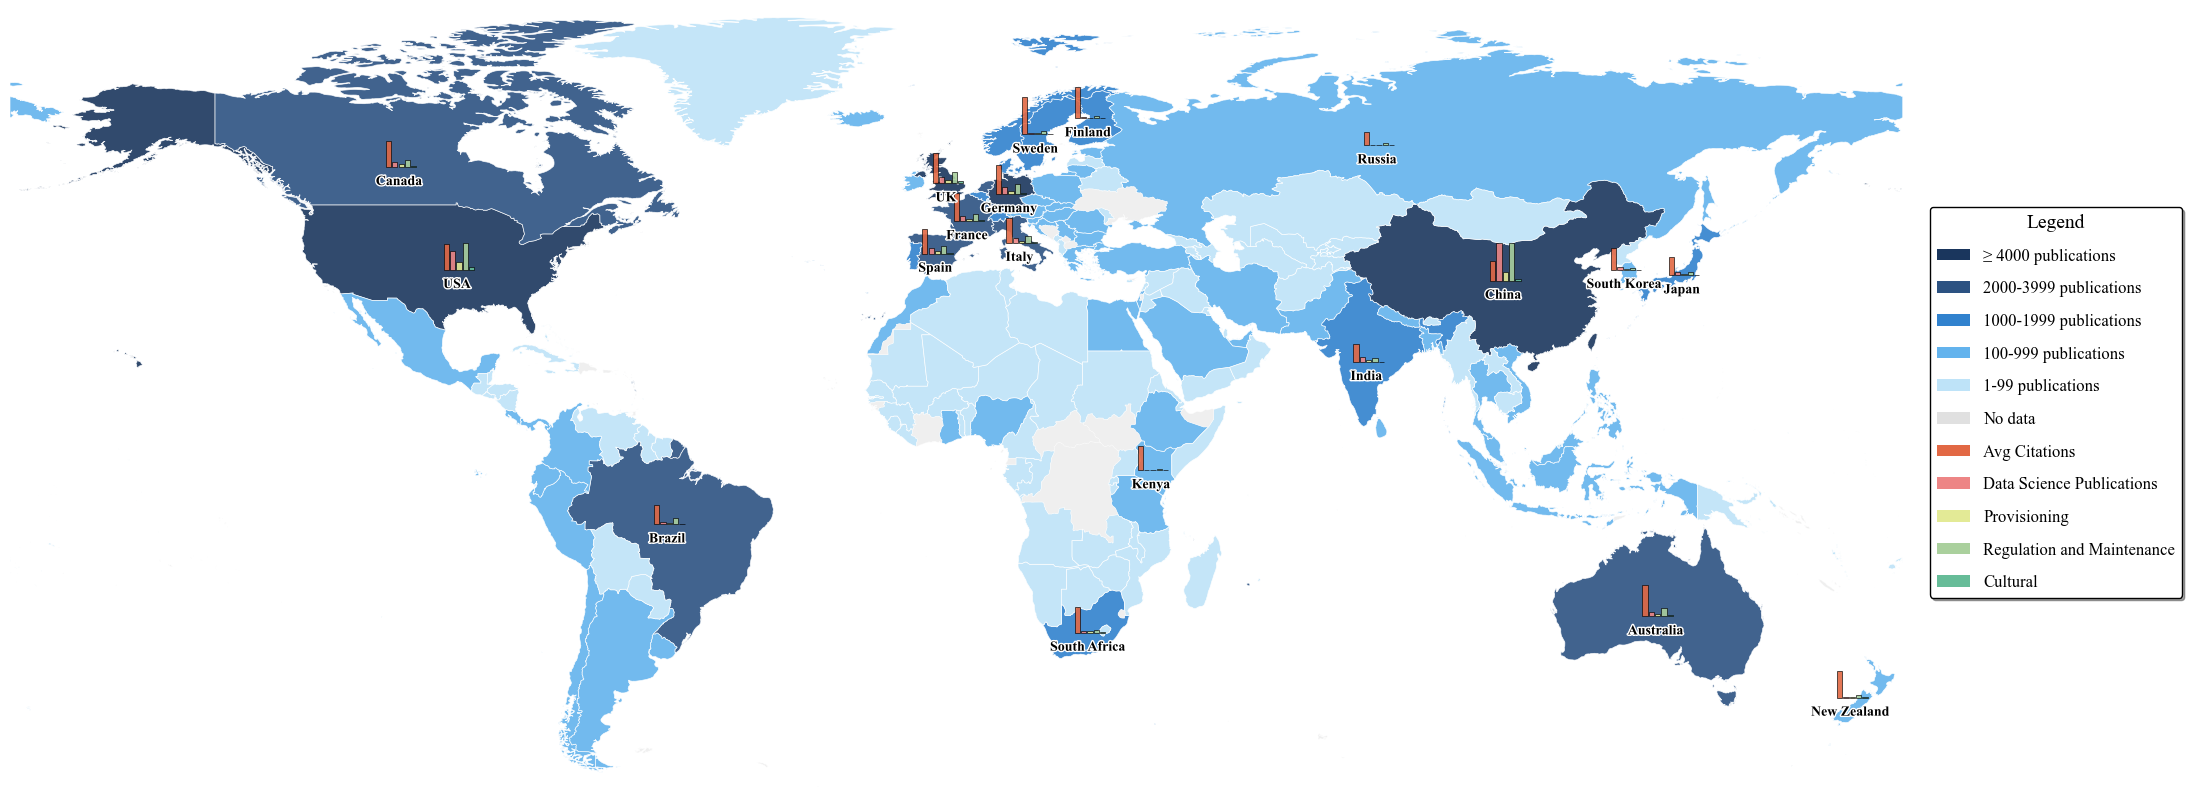


Map creation completed!
--------------------------------------------------------------------------------
Generated files:
- cices_publications_map_with_bars.png (CICES publication count graded map, DPI=600)


In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.patheffects as mpatheffects
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'serif']
plt.rcParams['axes.unicode_minus'] = False


class CICESWorldMap:
    def __init__(self, data_file="global_country_bibliometric_stats_cleaned.xlsx"):
        if not os.path.exists(data_file):
            raise FileNotFoundError(f"Data file {data_file} not found, please make sure the path is correct!")
            
        self.df_source = pd.read_excel(data_file)

        self.all_countries_cices = []
        for _, row in self.df_source.iterrows():
            self.all_countries_cices.append([row['Country'], row['Total_Articles'], row['Total_Citations']])

        self.detailed_countries_data = {}
        for _, row in self.df_source.iterrows():
            self.detailed_countries_data[row['Country']] = {
                'cices_citations': row['Total_Citations'],
                'ai_articles': row['AI_Methods'],
                'provision': row['Provisioning'],
                'regulating': row['Regulating'],
                'cultural': row['Cultural']
            }

        self.country_name_mapping = {
            'USA': 'United States of America', 
            'Peoples R China': 'China', 
            'China': 'China',
            'England': 'United Kingdom',
            'UK': 'United Kingdom', 
            'South Korea': 'South Korea', 
            'Korea, South': 'South Korea', 
            'Russia': 'Russia',
            'New Zealand': 'New Zealand', 
            'Czech Republic': 'Czechia',
            'Bosnia & Herceg': 'Bosnia and Herzegovina', 
            'Dem Rep Congo': 'Democratic Republic of the Congo',
            'Rep Congo': 'Republic of the Congo', 
            'Cent Afr Republ': 'Central African Republic',
            'Dominican Rep': 'Dominican Republic', 
            'North Korea': 'North Korea',
            'North Macedonia': 'North Macedonia', 
            'U Arab Emirates': 'United Arab Emirates',
            'UAE': 'United Arab Emirates',
            'Sao Tome & Prin': 'São Tomé and Príncipe', 
            'Trinidad Tobago': 'Trinidad and Tobago',
            'Papua N Guinea': 'Papua New Guinea', 
            'South Africa': 'South Africa', 
            'Kenya': 'Kenya'
        }

        self.cices_colors = ['#1a365d', '#2c5282', '#3182ce', '#63b3ed', '#bee3f8']
        self.cices_intervals = [
            (4000, float('inf'), '≥ 4000', 0),
            (2000, 3999, '2000-3999', 1),
            (1000, 1999, '1000-1999', 2),
            (100, 999, '100-999', 3),
            (1, 99, '1-99', 4)
        ]

    def prepare_data(self):
        df = pd.DataFrame(self.all_countries_cices, columns=['Country', 'CICES_Articles', 'CICES_Citations'])
        df['Country_Mapped'] = df['Country'].map(self.country_name_mapping).fillna(df['Country'])
        return df

    def assign_color_categories(self, df):
        df['CICES_Color_Category'] = 4
        for min_val, max_val, label, color_idx in self.cices_intervals:
            mask = (df['CICES_Articles'] >= min_val) & (df['CICES_Articles'] <= max_val)
            df.loc[mask, 'CICES_Color_Category'] = color_idx
        return df

    def load_world_map(self):
        try:
            local_path = "./50m_cultural/ne_50m_admin_0_countries.shp"
            if os.path.exists(local_path):
                world = gpd.read_file(local_path)
                print(f"Successfully loaded map data from local file: {local_path}")
                return world
            alternative_paths = [
                "./ne_50m_admin_0_countries.shp",
                "./50m_cultural/ne_50m_admin_0_countries_lakes.shp",
                "ne_50m_admin_0_countries.shp"
            ]
            for path in alternative_paths:
                if os.path.exists(path):
                    world = gpd.read_file(path)
                    print(f"Successfully loaded map data from local file: {path}")
                    return world
            print("Unable to find a local map file, trying to use the geopandas built-in low-resolution map...")
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            return world
        except Exception as e:
            print(f"Failed to load map data: {e}")
            return None

    def get_country_column_name(self, world):
        possible_columns = ['NAME', 'name', 'Country', 'country', 'ADMIN', 'admin', 'NAME_EN']
        for col in possible_columns:
            if col in world.columns:
                return col
        return 'NAME'

    def create_cices_map(self):
        df = self.prepare_data()
        df = self.assign_color_categories(df)
        detailed_df = self.prepare_detailed_data()
        world = self.load_world_map()
        if world is None:
            print("❌ Map loading failed, please check the environment!")
            return

        fig, ax = plt.subplots(figsize=(22, 14))
        country_col = self.get_country_column_name(world)
        world_data = world.merge(df, left_on=country_col, right_on='Country_Mapped', how='left')

        try:
            china_color = df[df['Country'] == 'China']['CICES_Color_Category'].iloc[0]
            world_data.loc[world_data[country_col] == 'Taiwan', 'CICES_Color_Category'] = china_color
        except IndexError: pass
        
        try:
            uk_color = df[df['Country'] == 'UK']['CICES_Color_Category'].iloc[0]
            world_data.loc[world_data[country_col] == 'United Kingdom', 'CICES_Color_Category'] = uk_color
        except IndexError: pass
        
        try:
            korea_color = df[df['Country'] == 'South Korea']['CICES_Color_Category'].iloc[0]
            korea_mask = world_data[country_col].str.contains('Korea', na=False) & ~world_data[country_col].str.contains('North', na=False)
            world_data.loc[korea_mask, 'CICES_Color_Category'] = korea_color
        except IndexError: pass
        
        world_data['CICES_Color_Category'] = world_data['CICES_Color_Category'].fillna(5)

        for i, (min_val, max_val, label, color_idx) in enumerate(self.cices_intervals):
            subset = world_data[world_data['CICES_Color_Category'] == color_idx]
            if not subset.empty:
                subset.plot(ax=ax, color=self.cices_colors[color_idx], edgecolor='white', linewidth=0.5, alpha=0.9)
        no_data = world_data[world_data['CICES_Color_Category'] == 5]
        if not no_data.empty:
            no_data.plot(ax=ax, color='#e0e0e0', alpha=0.5, edgecolor='white', linewidth=0.5)

        target_countries = ['USA', 'China', 'Germany', 'UK', 'Australia', 'Spain',
                            'Canada', 'France', 'Italy', 'Brazil', 'India', 'Sweden',
                            'Japan', 'Finland', 'New Zealand', 'Russia', 'South Korea',
                            'Kenya', 'South Africa']
        top_countries = detailed_df[detailed_df['Country'].isin(target_countries)]

        country_positions = {
            'USA': (-95, 37), 'China': (104, 35), 'Germany': (10, 51),
            'UK': (-2, 53), 'Australia': (133, -27), 'Spain': (-4, 40),
            'Canada': (-106, 56), 'France': (2, 46), 'Italy': (12, 42),
            'Brazil': (-55, -10), 'India': (78, 20), 'Sweden': (15, 62),
            'Japan': (138, 36), 'Finland': (25, 65), 'New Zealand': (170, -42),
            'Russia': (80, 60), 'South Korea': (127, 37), 'Kenya': (37, 0),
            'South Africa': (25, -30)
        }

        max_cices_avg = top_countries['Avg_Citations'].max() or 1
        max_ai = top_countries['AI_Articles'].max() or 1

        unified_max_category = max(
            top_countries['Provision_Articles'].max(),
            top_countries['Regulating_Articles'].max(),
            top_countries['Cultural_Articles'].max()
        )
        if unified_max_category == 0: unified_max_category = 1
        
        max_bar_height = 7
        bar_colors = ['#E26844', '#ED8585', '#E3EA96', '#AAD09D', '#66BC98']

        for _, country_data in top_countries.iterrows():
            country = country_data['Country']
            if country in country_positions:
                x, y = country_positions[country]

                values = [
                    country_data['Avg_Citations'] / max_cices_avg * max_bar_height,
                    country_data['AI_Articles'] / max_ai * max_bar_height,
                    country_data['Provision_Articles'] / unified_max_category * max_bar_height,
                    country_data['Regulating_Articles'] / unified_max_category * max_bar_height,
                    country_data['Cultural_Articles'] / unified_max_category * max_bar_height
                ]
                bar_width, bar_gap = 1.0, 0.2
                for i, (val, color) in enumerate(zip(values, bar_colors)):
                    rect_x = x - 2.5*bar_width + i*(bar_width + bar_gap)
                    ax.add_patch(plt.Rectangle((rect_x, y), bar_width, val,
                                      facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.9))
                txt = ax.text(x, y - 1.5, country, fontsize=10, fontweight='bold',
                              ha='center', va='top', fontfamily='Times New Roman', color='black')
                txt.set_path_effects([mpatheffects.Stroke(linewidth=2, foreground='white'),
                                      mpatheffects.Normal()])

        legend_elements = []
        for min_val, max_val, label, color_idx in self.cices_intervals:
            legend_elements.append(mpatches.Rectangle((0, 0), 1, 1,
                                                      facecolor=self.cices_colors[color_idx],
                                                      label=f'{label} publications'))
        legend_elements.append(mpatches.Rectangle((0, 0), 1, 1, facecolor='#e0e0e0', label='No data'))
        
        bar_labels = ['Avg Citations', 'Data Science Publications', 'Provisioning', 'Regulation and Maintenance', 'Cultural']
        for color, label in zip(bar_colors, bar_labels):
            legend_elements.append(mpatches.Rectangle((0, 0), 1, 1, facecolor=color, label=label))

        ax.legend(handles=legend_elements,
                  loc='center left', bbox_to_anchor=(1.01, 0.5),
                  title='Legend', fontsize=12, title_fontsize=14,
                  ncol=1, labelspacing=1.0, frameon=True, fancybox=True,
                  shadow=True, framealpha=1, edgecolor='black')

        ax.set_title('', fontsize=18, fontweight='bold', pad=20)
        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 85)
        ax.axis('off')

        plt.tight_layout()
        plt.savefig('cices_publications_map_with_bars.png', dpi=600, bbox_inches='tight', facecolor='white')
        plt.show()

    def prepare_detailed_data(self):
        """Since the Country names are now fully standardized, they can be matched one-to-one directly"""
        detailed_data = []
        for country, data in self.detailed_countries_data.items():
            cices_articles = 0
            for c_data in self.all_countries_cices:
                if c_data[0] == country:
                    cices_articles = c_data[1]
                    break
                    
            avg_citations = data['cices_citations'] / cices_articles if cices_articles > 0 else 0
            detailed_data.append({
                'Country': country,
                'CICES_Articles': cices_articles,
                'CICES_Citations': data['cices_citations'],
                'Avg_Citations': avg_citations,
                'AI_Articles': data['ai_articles'],
                'Provision_Articles': data['provision'],
                'Regulating_Articles': data['regulating'],
                'Cultural_Articles': data['cultural']
            })
        return pd.DataFrame(detailed_data)

    def print_data_summary(self):
        df = self.prepare_data()
        detailed_df = self.prepare_detailed_data()
        print("="*80)
        print("CICES Ecosystem Services Literature Data Summary (all 196+ countries/regions)")
        print("="*80)
        top_20 = df.nlargest(20, 'CICES_Articles')
        print(f"{'Rank':<4} {'Country/Region':<20} {'CICES Articles':<12} {'CICES Citations':<15}")
        print("-"*80)
        for i, (_, row) in enumerate(top_20.iterrows(), 1):
            print(f"{i:<4} {row['Country']:<20} {row['CICES_Articles']:<12} {row['CICES_Citations']:<15}")
        print("\n" + "="*80)
        print("Detailed data of the countries currently displayed:")
        print("-"*80)
        print(f"{'Country':<15} {'CICES Articles':<10} {'Avg Citation Rate':<12} {'AI Articles':<8} {'Prov':<6} {'Reg':<6} {'Cult':<6}")
        print("-"*80)
        for _, row in detailed_df.iterrows():
            print(f"{row['Country']:<15} {row['CICES_Articles']:<10} {row['Avg_Citations']:<12.2f} "
                  f"{row['AI_Articles']:<8} {row['Provision_Articles']:<6} "
                  f"{row['Regulating_Articles']:<6} {row['Cultural_Articles']:<6}")
        print("\n" + "="*80)

    def run_visualization(self):
        print("\n" + "="*80)
        print("Starting to create the CICES ecosystem services literature graded world map...")
        print("="*80 + "\n")
        print("Creating the CICES publication count graded map...")
        self.create_cices_map()
        print("\n" + "="*80)
        print("Map creation completed!")
        print("-"*80)
        print("Generated files:")
        print("- cices_publications_map_with_bars.png (CICES publication count graded map, DPI=600)")
        print("="*80)


if __name__ == "__main__":
    mapper = CICESWorldMap(data_file="global_country_bibliometric_stats_cleaned.xlsx")
    mapper.run_visualization()

In [8]:
import os
import re
from collections import Counter

class KeywordFrequencyAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.articles = []

        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR", "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        self.cices_categories = {
            'Provisioning': {
                'terrestrial_crops': ['crops', 'cereals', 'root crops', 'soft fruit', 'fodder', 'livestock feed', 'fibres', 'materials', 'cultivated plants', 'plantations', 'energy source', 'bioenergy'],
                'aquatic_crops': ['aquaculture', 'in-situ aquaculture', 'cultivated aquatic plants', 'algae'],
                'reared_animals': ['reared animals', 'beef', 'dairy', 'animal products', 'fibres from animals', 'mechanical energy', 'biogas'],
                'wild_plants': ['wild plants', 'terrestrial plants', 'aquatic plants', 'wild fungi', 'wild algae', 'wild plant materials', 'wild plant energy'],
                'wild_animals': ['wild animals', 'terrestrial animals', 'aquatic animals', 'wild animal nutrition', 'wild animal materials'],
                'water': ['surface water', 'ground water', 'drinking water', 'non-drinking water'],
                'genetic_material': ['seeds', 'spores', 'plant materials for breeding', 'new strains', 'varieties', 'individual genes', 'biological entities', 'animal genetic material']
            },
            'Regulating': {
                'biochemical_transformation': ['bio-remediation', 'micro-organisms', 'pollution degradation', 'filtration', 'sequestration', 'storage', 'accumulation', 'waste mediation', 'toxic substances', 'smell reduction', 'noise attenuation', 'visual screening'],
                'flow_extreme_events': ['erosion control', 'water erosion', 'wind erosion', 'hydrological cycle', 'water flow regulation', 'runoff', 'base flows', 'peak flows', 'hazard mitigation', 'mass movement', 'landslides', 'flood mitigation', 'surge protection', 'wind protection', 'fire protection'],
                'lifecycle_maintenance': ['pollination', 'gamete dispersal', 'seed dispersal', 'nursery populations', 'breeding grounds', 'gene pool protection', 'genetic diversity conservation', 'population establishment', 'refuge habitats', 'feeding grounds'],
                'pest_disease_control': ['pest control', 'invasive species management', 'disease control'],
                'soil_quality': ['soil quality', 'weathering processes', 'decomposition', 'fixing processes', 'soil structure', 'biological agents', 'soil porosity', 'role of bacteria', 'role of fungi'],
                'water_conditions': ['water conditions', 'chemical condition', 'macronutrients', 'freshwater regulation', 'saltwater regulation'],
                'atmospheric_conditions': ['atmospheric composition', 'oceanic circulation', 'climate change regulation', 'temperature regulation', 'humidity', 'ventilation', 'transpiration', 'microclimate']
            },
            'Cultural': {
                'physical_experiential': ['recreational activities', 'health promotion', 'recuperation', 'enjoyment', 'active interactions', 'immersive interactions', 'passive interactions', 'observational interactions'],
                'intellectual_representative': ['scientific investigation', 'traditional ecological knowledge', 'education', 'training', 'culture', 'heritage', 'cultural resonance', 'aesthetic experiences', 'entertainment', 'representation outside setting'],
                'spiritual_symbolic': ['symbolic meaning', 'sense of place', 'distinctiveness', 'spiritual meaning', 'religious meaning', 'sacred landscapes'],
                'existence_bequest_value': ['contemporary existence', 'conservation importance', 'inter-generational existence', 'bequest value', 'intrinsic value of biodiversity']
            }
        }

        self.cices_keywords = []
        for main_category, subcategories in self.cices_categories.items():
            for subcategory, keywords in subcategories.items():
                for keyword in keywords:
                    self.cices_keywords.append(keyword.lower().strip())

        self.cices_keywords = list(set(self.cices_keywords))
    
    def read_literature_files(self):
        """Read all literature files"""
        files = []
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']):
                files.append(f)
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    self.parse_articles(content)
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print(f"✅ Parsed {len(self.articles)} articles with keywords in total")
    
    def parse_articles(self, content):
        """Parse article content"""
        articles = re.split(r'\nER\s*\n', content)
        
        for article_text in articles:
            if not article_text.strip():
                continue
            
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            keywords = set()
            keywords_plus = set()

            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                id_content = id_match.group(1)
                kw_plus = self.extract_keywords_from_field(id_content)
                keywords_plus.update(kw_plus)

            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                de_content = de_match.group(1)
                kw = self.extract_keywords_from_field(de_content)
                keywords.update(kw)

            if keywords or keywords_plus:
                all_keywords = keywords | keywords_plus
                self.articles.append(all_keywords)
    
    def extract_keywords_from_field(self, field_content):
        """Extract keywords from ID or DE field content and clean up redundant symbols"""
        if not field_content:
            return []
        
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
        
        return cleaned_keywords
    
    def is_complete_word_match(self, article_keyword, target_keyword):
        """
        ⚠️ [Rigorous CICES frequency matching]
        Strictly check whether the underlying CICES keyword matches as a complete word or phrase.
        For example, matching "water" will absolutely not count "wastewater" in.
        """
        article_kw = article_keyword.lower().strip()
        target_kw = target_keyword.lower().strip()
        
        if article_kw == target_kw:
            return True

        if ' ' in target_kw:
            pattern = r'(?:^|\s)' + re.escape(target_kw) + r'(?:\s|$)'
        else:
            pattern = r'\b' + re.escape(target_kw) + r'\b'
        
        match_in_article = bool(re.search(pattern, article_kw))

        if ' ' in article_kw:
            reverse_pattern = r'(?:^|\s)' + re.escape(article_kw) + r'(?:\s|$)'
        else:
            reverse_pattern = r'\b' + re.escape(article_kw) + r'\b'
        match_in_target = bool(re.search(reverse_pattern, target_kw))
        
        return match_in_article or match_in_target
    
    def is_ai_keyword_match(self, search_text, ai_keyword):

        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        
        if search_text == ai_kw:
            return True
        
        strict_match_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        
        if ai_kw in strict_match_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
        
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))
    
    def count_keyword_frequencies(self):
        cices_counter = Counter()
        ai_counter = Counter()
        
        print("🔍 Starting precise underlying keyword frequency counting...")
        
        for article_keywords in self.articles:
            matched_cices = set()
            for article_keyword in article_keywords:
                for cices_keyword in self.cices_keywords:
                    if self.is_complete_word_match(article_keyword, cices_keyword):
                        matched_cices.add(cices_keyword)
            
            for cices_kw in matched_cices:
                cices_counter[cices_kw] += 1

            keywords_text = ' '.join(article_keywords)
            matched_ai = set()
            for ai_keyword in self.ai_keywords:
                if self.is_ai_keyword_match(keywords_text, ai_keyword):
                    matched_ai.add(ai_keyword)
            
            for ai_kw in matched_ai:
                ai_counter[ai_kw] += 1
        
        return cices_counter, ai_counter
    
    def print_frequency_report(self, cices_counter, ai_counter):
        """Print and export the frequency statistics report in the same directory"""
        print("\n" + "="*80)
        print("Specific Underlying Keyword Frequency Statistics Report (Precise Word Boundary Matching)")
        print("="*80)
        
        print(f"\n📊 Overall Statistics")
        print(f"  ├─ Total number of articles with keywords: {len(self.articles)}")
        print(f"  ├─ Number of CICES detailed keyword types actually captured: {len(cices_counter)}")
        print(f"  └─ Number of AI keyword types actually captured: {len(ai_counter)}")

        print(f"\n🌱 CICES Specific Keyword Frequencies (Top 50):")
        print("-" * 60)
        print(f"{'Rank':<6} {'Underlying Keyword':<30} {'Frequency':<10}")
        print("-" * 60)
        
        for i, (keyword, freq) in enumerate(cices_counter.most_common(50), 1):
            keyword_display = keyword[:28] + '..' if len(keyword) > 30 else keyword
            print(f"{i:<6} {keyword_display:<30} {freq:<10}")

        print(f"\n🤖 AI Keyword Frequencies (Top 50):")
        print("-" * 60)
        print(f"{'Rank':<6} {'AI Technology Term':<30} {'Frequency':<10}")
        print("-" * 60)
        
        for i, (keyword, freq) in enumerate(ai_counter.most_common(50), 1):
            keyword_display = keyword[:28] + '..' if len(keyword) > 30 else keyword
            print(f"{i:<6} {keyword_display:<30} {freq:<10}")

        with open('keyword_frequencies.txt', 'w', encoding='utf-8') as f:
            f.write("CICES Underlying Specific Term Frequency Statistics (based on strict word boundary matching)\n")
            f.write("-" * 50 + "\n")
            for keyword, freq in cices_counter.most_common():
                f.write(f"{keyword}\t{freq}\n")
            
            f.write("\n\nAI Core Technology Frequency Statistics (based on strict false-positive-proof matching)\n")
            f.write("-" * 50 + "\n")
            for keyword, freq in ai_counter.most_common():
                f.write(f"{keyword}\t{freq}\n")
        
        print("\n✅ The complete statistical results have been safely saved to the keyword_frequencies.txt file in the same directory")
    
    def run(self):
        """Run the frequency counting engine"""
        print("🔗 Mounting the rigorous frequency counting module for CICES and AI keywords...")
        print("="*80)
        
        self.read_literature_files()
        
        if not self.articles:
            print("❌ Warning: no valid literature keyword data found!")
            return
        
        cices_counter, ai_counter = self.count_keyword_frequencies()
        self.print_frequency_report(cices_counter, ai_counter)
        
        print("\n" + "="*80)
        print("✅ Detailed keyword frequency counting completed!")
        print("="*80)


if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = KeywordFrequencyAnalyzer(data_directory=TARGET_DIR)
    analyzer.run()

🔗 Mounting the rigorous frequency counting module for CICES and AI keywords...
📚 Found 12 literature files
✅ Parsed 53227 articles with keywords in total
🔍 Starting precise underlying keyword frequency counting...

Specific Underlying Keyword Frequency Statistics Report (Precise Word Boundary Matching)

📊 Overall Statistics
  ├─ Total number of articles with keywords: 53227
  ├─ Number of CICES detailed keyword types actually captured: 135
  └─ Number of AI keyword types actually captured: 173

🌱 CICES Specific Keyword Frequencies (Top 50):
------------------------------------------------------------
Rank   Underlying Keyword             Frequency 
------------------------------------------------------------
1      genetic diversity conservation 8671      
2      intrinsic value of biodivers.. 7919      
3      invasive species management    5981      
4      conservation importance        4886      
5      climate change regulation      4701      
6      soil quality                  